# Frozen v14/v15/v16/v17 seed-1 100k qualification comparison and RCA

## TL;DR

- This notebook reads only the four frozen qualification runs and applies the exact population predicate `70000 < real_step <= 100000`; terminal overshoots 100112 (v14), 100736 (v15), and 100432 (v16) are excluded, while v17 ends exactly at 100000.
- Support-weighted held-out EMA selected-action TD RMSE is **0.5247954789** (v14, N=7,703), **0.5637126652** (v15, N=8,154), **0.6433996229** (v16, N=7,535), and **0.4739621233** (v17, N=5,748). V17 alone clears the unchanged `<= 0.5` RMSE ceiling.
- V17 nevertheless fails qualification because seven of 32 trailing-five endpoints have zero positive-sign support: 74544, 75568, 76576, 77616, 78656, 79680, and 80656. W1 has zero positive support in aggregate; positive support later recovers in W2/W3. Undefined endpoints are failures, never zero or nonnegative gaps.
- V16 fails both RMSE and denominator validity; v14/v15 fail RMSE only. All four runs complete their mechanics and safety checks, but a numeric failure cannot be rescued by successful mechanics.
- The four cells form an observed 2x2 of Huber versus half-MSE and centered-only versus common-mode reconstruction. They are single-seed, separately generated, policy-coupled trajectories, not paired factorial observations.
- Comparisons below are descriptive evidence and falsifiable RCA hypotheses, not causal attribution, a pass prediction, or authorization to launch, evaluate, retry, rescue, or implement another version.


## Context & Methods

**Scope.** Numeric inputs are frozen `logs.csv` and `logs_model.csv` files under the immutable v14/v15/v16/v17 snapshots. Exact CSV, actor checkpoint, model checkpoint, config, finish, protocol-document, source-manifest, data-manifest, and launch-provenance hashes are asserted before analysis. Four trusted step checkpoints—V16 step 480, V16 terminal step 100432, V17 step 480, and V17 terminal step 100000—are SHA-256 verified. Three of them (V16 step 480, V17 step 480, and V17 terminal step 100000) are then deserialized read-only with `torch.load(..., map_location='cpu', weights_only=False)` solely for tensor, Adam-moment, projection, and frozen-denominator leakage diagnostics; no checkpoint is written back. No training, evaluation, fixed evaluation, retry, resume, or environment action is invoked.

**Protocol population.** Rows remain in CSV order and must be complete, finite, unique, and strictly increasing in `real_step`. Canonical qualification rows satisfy the strict predicate `70000 < real_step <= 100000`; windows are W1 `(70000,80000]`, W2 `(80000,90000]`, and W3 `(90000,100000]`. Overshoot is excluded rather than clipped, paired, interpolated, or replaced.

**Pooling.** A mean is `sum(row_support * row_value) / sum(row_support)`. RMSE is `sqrt(sum(row_support * row_rmse**2) / sum(row_support))`. Trailing-five student gaps pool positive and negative sufficient statistics independently over each five-row window. A missing sign denominator fails the denominator-validity gate; exactly zero gap is nonnegative.

**Interpretive boundary.** Window, composition, loss, cadence, and update-norm summaries are observational diagnostics. The 2x2 is descriptive rather than factorial: loss, reconstruction, learned states, support, update cadence, and closed-loop trajectory are not independently randomized. Event-level residual quantiles and counterfactual residuals cannot be reconstructed from row aggregates.


In [1]:
from pathlib import Path
import csv
import hashlib
import json
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PRODUCTION_PYTHON = Path('/home/jeongmin/miniconda-dynamic/envs/dynamic-thinker/bin/python')
VERSIONS = {
    'v14': {
        'snapshot': Path('/tmp/di-voc-v14-sealed-eps25-final-eKgdrk'),
        'xpid': 'enduro-voc-v14-sealed-eps25-seed1-qual-fresh-100k',
        'actor_sha256': '6d72052279a59983d102bed3db767b3792b115d221f155cdd10d4dc29bbe85a8',
        'actor_shape': (204, 922),
        'model_sha256': 'b38dfd254fab250394ca463c4371c573b8c37f332e5f5f0b43c6d9b5fbfc3f64',
        'model_shape': (230, 52),
        'actor_checkpoint_sha256': 'a86094cc3131bbe55bd5ac5995203cf8f3830ab36fbaf60e630306b0fe1d107c',
        'model_checkpoint_sha256': '6d6c2ff3ba5335337476998eb13be6ea80e9962d5ffabc67ade3020cb362af7a',
        'config_sha256': '97d6a78d78d0d49dbd3e038fa77f268c29d4b21244c98d345060505f70c40350',
        'finish_sha256': '5ea6592e5f57cafb908902eed9decd7535e78d4e9b9fa33c23f7bf00b16f3b4e',
        'loss': 'Huber beta=1', 'reconstruction': 'centered-only',
        'launch': Path('/tmp/v14qual100-hZGppv/launch_provenance.txt'),
        'launch_sha256': '0e9f4ad97ea5774ccc579da43118546b1c837d6e21ceaa3b9be8d7d330af5b54',
        'protocol_rel': 'src/VOC_V14_SEALED_MODEL_INPUT_300K_ACCEPTANCE.md',
        'protocol_sha256': 'f422089ec4df7479f89477a3e6e63744dc74d06d1ceab9d5ea10397b34500972',
        'source_manifest_sha256': '4fa507706250f349acfb6034453f1e8c70681c54e9e52718d848cd81755dbfea',
        'data_manifest_sha256': '23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343',
        'canonical': {'rows': 63, 'first': 70032, 'last': 99376, 'support': 7703, 'overshoot': [100112]},
    },
    'v15': {
        'snapshot': Path('/tmp/di-voc-v15-halfsq-eps25-final-CKcYfI'),
        'xpid': 'enduro-voc-v15-halfsq-eps25-seed1-qual-fresh-100k',
        'actor_sha256': '359eb6540a6265a2a5b8e77fa8ac01420b5f0077a3b84d67800f0308f448e341',
        'actor_shape': (149, 922),
        'model_sha256': '360e6d475d635f734e4b14ddfff7a0022ba7997131785ce2ee7a39ea28b6839b',
        'model_shape': (189, 52),
        'actor_checkpoint_sha256': 'ee41fa3f0916f5b726b6cd448e12989abbe01554a69c6f4eb5ab8ed434cd2c7c',
        'model_checkpoint_sha256': '8d215ce13489735e685ed1d271ad857b69f23f0b35213447d0d90f67f96b82b8',
        'config_sha256': 'edd3ce926dbb048543a1ea11ee0bca29bef2f83c88877f3ae1e4d85308e234b2',
        'finish_sha256': 'e2d00bf7baa7276cca91bf1c73e025991e5d1c1ddfc6236ab8cec71c845d8184',
        'loss': 'half-MSE', 'reconstruction': 'centered-only',
        'launch': Path('/tmp/v15qual-JhNlYp/launch_provenance.txt'),
        'launch_sha256': 'ad1e625579aad7e9c400a4a85130939400ed1e0696b8c71987ce8e3bbfda9ccd',
        'protocol_rel': 'src/VOC_V15_HALF_SQUARED_Q_300K_ACCEPTANCE.md',
        'protocol_sha256': 'cf5838f577ac55db2990669ebfd712c6cbbeee28e8b5388075833b69f4206b90',
        'source_manifest_sha256': '1c2d619479a63d75f0b23c41ef293f611b3631432356067a2db425a30ec62cdf',
        'data_manifest_sha256': '23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343',
        'canonical': {'rows': 58, 'first': 70240, 'last': 99920, 'support': 8154, 'overshoot': [100736]},
    },
    'v16': {
        'snapshot': Path('/tmp/di-voc-v16-commonmode-eps25-final-mZ6A2C'),
        'xpid': 'enduro-voc-v16-commonmode-eps25-seed1-qual-fresh-100k',
        'actor_sha256': '45da4532357f5f150fad15c47bf1cdbb5ec52738ff3a68678afb5dca73ed20d5',
        'actor_shape': (250, 922),
        'model_sha256': 'ef5e39aba9ad5b7c0c2b4bef34ba91bb6f3adf1bcdc940abe9915504b8b18225',
        'model_shape': (276, 52),
        'actor_checkpoint_sha256': 'c05a2237b495ff36fe633446e8236a93d2e07da9038f01781ac3b5026e947b7d',
        'model_checkpoint_sha256': 'd1ce735542c5dd4a89b4e8cdc550946b5417700a956468820a69e4d80ed9ea58',
        'config_sha256': '2c91aa82c4744a8f44320ec5cc95f797384c4467c17607420b1dc3a94d9fea6b',
        'finish_sha256': '1b5f3449f685f876a10bbad21bacad4c0cd28479d53bcb0197f18308e2cb286f',
        'loss': 'half-MSE', 'reconstruction': 'common-mode',
        'launch': Path('/tmp/v16qual-G3LwWW/launch_provenance.txt'),
        'launch_sha256': '1b712c604387725ccdc4aa1dbdcb016f4b4cb5c9b0effa22f150e27daf035325',
        'protocol_rel': 'src/VOC_V16_COMMON_MODE_Q_300K_ACCEPTANCE.md',
        'protocol_sha256': '1814d68f667748358746c42f4578e17acbb950e9e0adac04a8d78c9352fdb84c',
        'source_manifest_sha256': 'f90b970c647b06884f1101a3b39d862eed97aec51d69013614b6b671f54112ea',
        'data_manifest_sha256': '23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343',
        'canonical': {'rows': 52, 'first': 70032, 'last': 99408, 'support': 7535, 'overshoot': [100432]},
    },
    'v17': {
        'snapshot': Path('/tmp/di-voc-v17-huber-common-eps25-final-Tmc42l'),
        'xpid': 'enduro-voc-v17-huber-common-eps25-seed1-qual-fresh-100k',
        'actor_sha256': 'e50308619550a45e8bc722bd152722f96723f2b448885ae2e5ec65227f21d030',
        'actor_shape': (143, 922),
        'model_sha256': '2801e56a80dc8e3db20dcf0f22109a259e0a7fd6b31e4d1d2054fdd2ef75b564',
        'model_shape': (185, 52),
        'actor_checkpoint_sha256': '1054956ebbb8a1b75cb1d2eed54611c90d785c83ee3fc9a7d6d40e2c85430eb0',
        'model_checkpoint_sha256': 'aca6d46ba749fd5394525918f6a6a822f0ac7f3377b7c953b511662012bf1a15',
        'config_sha256': 'f5d900bd2b6d0b25a628869b3dc90424e4a8018e888e88ace81a4f88d217b971',
        'finish_sha256': '65f4c77efedbaaeaffe4a90cde00c8c4292942a3b5e3a5c7a39eba4b3acebff7',
        'loss': 'Huber beta=1', 'reconstruction': 'common-mode',
        'launch': Path('/tmp/v17qual-o7qrEu/launch_provenance.txt'),
        'launch_sha256': '17aebc1ec40196fa51205eb8ea208fb96b04750941abd44c9fc2bba589232905',
        'protocol_rel': 'src/VOC_V17_HUBER_COMMON_Q_300K_ACCEPTANCE.md',
        'protocol_sha256': '9d032579808f5cc07253e654feea9f4f80fe45151701fd4864896bf486c267a1',
        'source_manifest_sha256': '87d17a63953caf41f62b92454e13ff92498c590eef9f6e156282e9e7e1d767ac',
        'data_manifest_sha256': '23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343',
        'canonical': {'rows': 36, 'first': 70416, 'last': 100000, 'support': 5748, 'overshoot': []},
    },
}
for spec in VERSIONS.values():
    run_dir = spec['snapshot'] / 'runs' / spec['xpid']
    spec['actor_csv'] = run_dir / 'logs.csv'
    spec['model_csv'] = run_dir / 'logs_model.csv'
    spec['actor_checkpoint'] = run_dir / 'ckp_actor.tar'
    spec['model_checkpoint'] = run_dir / 'ckp_model.tar'
    spec['config'] = run_dir / 'config_c.yaml'
    spec['finish'] = run_dir / 'finish'
    spec['source_manifest'] = spec['snapshot'] / 'source.sha256'
    spec['data_manifest'] = spec['snapshot'] / 'enduro_data.sha256'
    spec['protocol'] = spec['snapshot'] / spec['protocol_rel']

WINDOWS = (('W1', 70000, 80000), ('W2', 80000, 90000), ('W3', 90000, 100000))
LOWER_STEP, UPPER_STEP, RMSE_CEILING = 70000, 100000, 0.5
COLORS = {'v14': '#2F6BFF', 'v15': '#F59E0B', 'v16': '#D946EF', 'v17': '#0F766E'}
rendered_figure_count = 0

assert sys.version_info[:3] == (3, 10, 21), sys.version
assert Path(sys.executable).resolve() == PRODUCTION_PYTHON.resolve(), sys.executable
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.18, 'font.size': 9})
print(f'Python {platform.python_version()} | {sys.executable}')
print(f'pandas={pd.__version__}, numpy={np.__version__}, matplotlib={plt.matplotlib.__version__}')


Python 3.10.21 | /home/jeongmin/miniconda-dynamic/envs/dynamic-thinker/bin/python3.10
pandas=2.3.3, numpy=1.26.4, matplotlib=3.10.9


## Data validation

The next cell fails closed on any byte drift, schema drift, incomplete actor row, non-finite actor numeric cell, non-integral/nonmonotone actor step, population mismatch, or provenance mismatch. `logs_model.csv` is hash/shape/schema bound but is not used to substitute any actor sufficient statistic. Its repeated/asynchronous `real_step` values are therefore not treated as actor qualification rows.


In [2]:
def sha256_file(path):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for block in iter(lambda: handle.read(1 << 20), b''):
            digest.update(block)
    return digest.hexdigest()

def parse_provenance(path):
    return dict(line.split('=', 1) for line in path.read_text(encoding='utf-8').splitlines() if '=' in line)

frames, canonical, actor_headers, model_headers = {}, {}, {}, {}
quality_rows = []
for version, spec in VERSIONS.items():
    for key in ('actor_csv', 'model_csv', 'actor_checkpoint', 'model_checkpoint', 'config', 'finish', 'source_manifest', 'data_manifest', 'launch', 'protocol'):
        assert spec[key].is_file(), spec[key]
    actor_hash = sha256_file(spec['actor_csv'])
    model_hash = sha256_file(spec['model_csv'])
    launch_hash = sha256_file(spec['launch'])
    protocol_hash = sha256_file(spec['protocol'])
    actor_checkpoint_hash = sha256_file(spec['actor_checkpoint'])
    model_checkpoint_hash = sha256_file(spec['model_checkpoint'])
    config_hash = sha256_file(spec['config'])
    finish_hash = sha256_file(spec['finish'])
    source_manifest_hash = sha256_file(spec['source_manifest'])
    data_manifest_hash = sha256_file(spec['data_manifest'])
    assert actor_hash == spec['actor_sha256'], (version, 'actor', actor_hash)
    assert model_hash == spec['model_sha256'], (version, 'model', model_hash)
    assert launch_hash == spec['launch_sha256'], (version, 'launch', launch_hash)
    assert protocol_hash == spec['protocol_sha256'], (version, 'protocol', protocol_hash)
    assert actor_checkpoint_hash == spec['actor_checkpoint_sha256'], (version, 'actor checkpoint', actor_checkpoint_hash)
    assert model_checkpoint_hash == spec['model_checkpoint_sha256'], (version, 'model checkpoint', model_checkpoint_hash)
    assert config_hash == spec['config_sha256'], (version, 'config', config_hash)
    assert finish_hash == spec['finish_sha256'], (version, 'finish', finish_hash)
    assert source_manifest_hash == spec['source_manifest_sha256'], (version, 'source manifest', source_manifest_hash)
    assert data_manifest_hash == spec['data_manifest_sha256'], (version, 'data manifest', data_manifest_hash)
    with spec['actor_csv'].open('r', encoding='utf-8', newline='') as handle:
        actor_header = next(csv.reader(handle))
    with spec['model_csv'].open('r', encoding='utf-8', newline='') as handle:
        model_header = next(csv.reader(handle))
    assert len(actor_header) == len(set(actor_header)) == 922
    assert len(model_header) == len(set(model_header)) == 52
    frame = pd.read_csv(spec['actor_csv'])
    model_frame = pd.read_csv(spec['model_csv'])
    assert frame.shape == spec['actor_shape'], (version, frame.shape)
    assert model_frame.shape == spec['model_shape'], (version, model_frame.shape)
    assert list(frame.columns) == actor_header and list(model_frame.columns) == model_header
    assert frame.notna().all(axis=1).all(), version
    numeric = frame.select_dtypes(include=[np.number])
    assert numeric.shape[1] == 917 and np.isfinite(numeric.to_numpy(dtype=np.float64)).all()
    steps = pd.to_numeric(frame['real_step'], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(steps).all() and np.equal(steps, np.rint(steps)).all()
    assert np.all(np.diff(steps) > 0) and frame.real_step.is_unique
    population = frame.loc[(frame.real_step > LOWER_STEP) & (frame.real_step <= UPPER_STEP)].copy().reset_index(drop=True)
    overshoot = frame.loc[frame.real_step > UPPER_STEP, 'real_step'].astype(int).tolist()
    expected = spec['canonical']
    assert len(population) == expected['rows']
    assert (int(population.real_step.iloc[0]), int(population.real_step.iloc[-1])) == (expected['first'], expected['last'])
    assert overshoot == expected['overshoot']
    provenance = parse_provenance(spec['launch'])
    assert provenance['snapshot'] == str(spec['snapshot'])
    assert provenance['xpid'] == spec['xpid']
    assert Path(provenance['python']).resolve() == PRODUCTION_PYTHON.resolve()
    assert provenance['source_manifest_sha256'] == spec['source_manifest_sha256']
    assert provenance['data_manifest_sha256'] == spec['data_manifest_sha256']
    frames[version], canonical[version] = frame, population
    actor_headers[version], model_headers[version] = actor_header, model_header
    quality_rows.append({
        'version': version, 'actor_csv_sha256': actor_hash, 'model_csv_sha256': model_hash,
        'launch_sha256': launch_hash, 'protocol_sha256': protocol_hash,
        'actor_checkpoint_sha256': actor_checkpoint_hash, 'model_checkpoint_sha256': model_checkpoint_hash,
        'config_sha256': config_hash, 'finish_sha256': finish_hash,
        'actor_shape': str(frame.shape), 'model_shape': str(model_frame.shape),
        'canonical_rows': len(population), 'first_step': int(population.real_step.iloc[0]),
        'last_step': int(population.real_step.iloc[-1]), 'excluded_overshoot': json.dumps(overshoot),
        'source_manifest_sha256': provenance['source_manifest_sha256'],
        'data_manifest_sha256': provenance['data_manifest_sha256'],
    })
assert actor_headers['v14'] == actor_headers['v15'] == actor_headers['v16'] == actor_headers['v17']
assert model_headers['v14'] == model_headers['v15'] == model_headers['v16'] == model_headers['v17']
data_quality = pd.DataFrame(quality_rows)
display(data_quality)
print('Exact actor/model schemas are ordered-identical across v14/v15/v16/v17; actor rows are complete and finite; model CSV is hash/shape/schema bound only.')


,version,actor_csv_sha256,model_csv_sha256,launch_sha256,protocol_sha256,actor_checkpoint_sha256,model_checkpoint_sha256,config_sha256,finish_sha256,actor_shape,model_shape,canonical_rows,first_step,last_step,excluded_overshoot,source_manifest_sha256,data_manifest_sha256
0,v14,6d72052279a59983d102bed3db767b3792b115d221f155cdd10d4dc29bbe85a8,b38dfd254fab250394ca463c4371c573b8c37f332e5f5f0b43c6d9b5fbfc3f64,0e9f4ad97ea5774ccc579da43118546b1c837d6e21ceaa3b9be8d7d330af5b54,f422089ec4df7479f89477a3e6e63744dc74d06d1ceab9d5ea10397b34500972,a86094cc3131bbe55bd5ac5995203cf8f3830ab36fbaf60e630306b0fe1d107c,6d6c2ff3ba5335337476998eb13be6ea80e9962d5ffabc67ade3020cb362af7a,97d6a78d78d0d49dbd3e038fa77f268c29d4b21244c98d345060505f70c40350,5ea6592e5f57cafb908902eed9decd7535e78d4e9b9fa33c23f7bf00b16f3b4e,"(204, 922)","(230, 52)",63,70032,99376,[100112],4fa507706250f349acfb6034453f1e8c70681c54e9e52718d848cd81755dbfea,23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343
1,v15,359eb6540a6265a2a5b8e77fa8ac01420b5f0077a3b84d67800f0308f448e341,360e6d475d635f734e4b14ddfff7a0022ba7997131785ce2ee7a39ea28b6839b,ad1e625579aad7e9c400a4a85130939400ed1e0696b8c71987ce8e3bbfda9ccd,cf5838f577ac55db2990669ebfd712c6cbbeee28e8b5388075833b69f4206b90,ee41fa3f0916f5b726b6cd448e12989abbe01554a69c6f4eb5ab8ed434cd2c7c,8d215ce13489735e685ed1d271ad857b69f23f0b35213447d0d90f67f96b82b8,edd3ce926dbb048543a1ea11ee0bca29bef2f83c88877f3ae1e4d85308e234b2,e2d00bf7baa7276cca91bf1c73e025991e5d1c1ddfc6236ab8cec71c845d8184,"(149, 922)","(189, 52)",58,70240,99920,[100736],1c2d619479a63d75f0b23c41ef293f611b3631432356067a2db425a30ec62cdf,23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343
2,v16,45da4532357f5f150fad15c47bf1cdbb5ec52738ff3a68678afb5dca73ed20d5,ef5e39aba9ad5b7c0c2b4bef34ba91bb6f3adf1bcdc940abe9915504b8b18225,1b712c604387725ccdc4aa1dbdcb016f4b4cb5c9b0effa22f150e27daf035325,1814d68f667748358746c42f4578e17acbb950e9e0adac04a8d78c9352fdb84c,c05a2237b495ff36fe633446e8236a93d2e07da9038f01781ac3b5026e947b7d,d1ce735542c5dd4a89b4e8cdc550946b5417700a956468820a69e4d80ed9ea58,2c91aa82c4744a8f44320ec5cc95f797384c4467c17607420b1dc3a94d9fea6b,1b5f3449f685f876a10bbad21bacad4c0cd28479d53bcb0197f18308e2cb286f,"(250, 922)","(276, 52)",52,70032,99408,[100432],f90b970c647b06884f1101a3b39d862eed97aec51d69013614b6b671f54112ea,23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343
3,v17,e50308619550a45e8bc722bd152722f96723f2b448885ae2e5ec65227f21d030,2801e56a80dc8e3db20dcf0f22109a259e0a7fd6b31e4d1d2054fdd2ef75b564,17aebc1ec40196fa51205eb8ea208fb96b04750941abd44c9fc2bba589232905,9d032579808f5cc07253e654feea9f4f80fe45151701fd4864896bf486c267a1,1054956ebbb8a1b75cb1d2eed54611c90d785c83ee3fc9a7d6d40e2c85430eb0,aca6d46ba749fd5394525918f6a6a822f0ac7f3377b7c953b511662012bf1a15,f5d900bd2b6d0b25a628869b3dc90424e4a8018e888e88ace81a4f88d217b971,65f4c77efedbaaeaffe4a90cde00c8c4292942a3b5e3a5c7a39eba4b3acebff7,"(143, 922)","(185, 52)",36,70416,100000,[],87d17a63953caf41f62b92454e13ff92498c590eef9f6e156282e9e7e1d767ac,23c32c10236c15a53f27ecbe9e49dc2edbddfc5b132dcece22700ad07ef68343


Exact actor/model schemas are ordered-identical across v14/v15/v16/v17; actor rows are complete and finite; model CSV is hash/shape/schema bound only.


## Results

### 1. Reproduce CSV-observable hard gates

Integrity gates outside the CSV sufficient statistics remain governed by their frozen terminal bundles and validators; this notebook does not replace them. The table below reproduces every inherited gate available from the frozen actor CSVs. For trailing-five, denominator validity and maximum negative run are separate gates: undefined windows cannot be silently counted as nonnegative.


In [3]:
HOLDOUT_COUNT = 'actor/voc_holdout_count'
GATE_PREFIX = 'actor/voc_gate_acceptance'

def require_counts(series, label):
    values = pd.to_numeric(series, errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(values).all() and (values >= 0).all(), label
    assert np.allclose(values, np.rint(values), rtol=0.0, atol=1e-9), label
    return values.astype(np.int64)

def pooled_mean(frame, value_column, count_column, allow_zero=False):
    counts = require_counts(frame[count_column], count_column).astype(np.float64)
    values = pd.to_numeric(frame[value_column], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(values).all()
    if counts.sum() == 0:
        assert allow_zero
        return np.nan
    return float(np.dot(counts, values) / counts.sum())

def pooled_rmse(frame, rmse_column, count_column=HOLDOUT_COUNT):
    counts = require_counts(frame[count_column], count_column).astype(np.float64)
    values = pd.to_numeric(frame[rmse_column], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(values).all() and (values >= 0).all() and counts.sum() > 0
    return float(np.sqrt(np.dot(counts, np.square(values)) / counts.sum()))

def reconstructed_event_rate(frame, count_column, rate_column, tolerance=1e-4):
    counts = require_counts(frame[count_column], count_column)
    rates = pd.to_numeric(frame[rate_column], errors='raise').to_numpy(dtype=np.float64)
    assert np.isfinite(rates).all() and ((rates >= 0) & (rates <= 1)).all()
    raw = counts.astype(np.float64) * rates
    successes = np.rint(raw).astype(np.int64)
    residual = np.abs(raw - successes)
    assert (residual <= tolerance).all(), (count_column, rate_column, float(residual.max()))
    return int(successes.sum()), int(counts.sum()), float(residual.max())

def gap_metrics(frame, allow_zero=False):
    positive_count = f'{GATE_PREFIX}_delta_q_positive_count'
    negative_count = f'{GATE_PREFIX}_delta_q_negative_count'
    nontie_count = f'{GATE_PREFIX}_delta_q_nontie_count'
    teacher_positive = pooled_mean(frame, f'{GATE_PREFIX}_teacher_continue_probability_delta_positive', positive_count, allow_zero)
    teacher_negative = pooled_mean(frame, f'{GATE_PREFIX}_teacher_continue_probability_delta_negative', negative_count, allow_zero)
    student_positive = pooled_mean(frame, f'{GATE_PREFIX}_continue_probability_delta_positive', positive_count, allow_zero)
    student_negative = pooled_mean(frame, f'{GATE_PREFIX}_continue_probability_delta_negative', negative_count, allow_zero)
    teacher_gap = teacher_positive - teacher_negative
    student_gap = student_positive - student_negative
    signed_margin = pooled_mean(frame, f'{GATE_PREFIX}_signed_gate_margin', nontie_count)
    retention = student_gap / teacher_gap if np.isfinite(teacher_gap) and teacher_gap != 0 else np.nan
    return teacher_gap, student_gap, retention, signed_margin

def trailing_five(frame):
    positive_count = f'{GATE_PREFIX}_delta_q_positive_count'
    negative_count = f'{GATE_PREFIX}_delta_q_negative_count'
    positive_value = f'{GATE_PREFIX}_continue_probability_delta_positive'
    negative_value = f'{GATE_PREFIX}_continue_probability_delta_negative'
    records = []
    for endpoint in range(4, len(frame)):
        window = frame.iloc[endpoint - 4:endpoint + 1]
        positive_n = int(require_counts(window[positive_count], positive_count).sum())
        negative_n = int(require_counts(window[negative_count], negative_count).sum())
        gap = np.nan
        if positive_n > 0 and negative_n > 0:
            gap = pooled_mean(window, positive_value, positive_count) - pooled_mean(window, negative_value, negative_count)
        records.append({'real_step': int(frame.real_step.iloc[endpoint]), 'positive_n': positive_n, 'negative_n': negative_n, 'student_gap': gap})
    result = pd.DataFrame(records)
    run = max_run = 0
    for is_negative in (result.student_gap < 0).tolist():
        run = run + 1 if is_negative else 0
        max_run = max(max_run, run)
    return result, max_run

SAFETY_COLUMNS = [
    'actor/amp_skip_count', 'actor/amp_consecutive_skips', 'actor/nonfinite_gradient_parameter_count',
    'voc/amp_skip_count', 'voc/amp_consecutive_skips', 'voc/nonfinite_gradient_parameter_count',
    'voc_gate/amp_skip_count', 'voc_gate/amp_consecutive_skips', 'voc_gate/nonfinite_gradient_parameter_count',
    'voc_actor_policy_version_mismatch_count', 'voc_actor_policy_malformed_bundle_count', 'voc_actor_policy_barrier_timeout_count',
]

authoritative, trailing_results, detail_rows = {}, {}, []
for version, frame in canonical.items():
    teacher_gap, student_gap, retention, signed_margin = gap_metrics(frame)
    positive_windows = 0
    for _, lower, upper in WINDOWS:
        window = frame.loc[(frame.real_step > lower) & (frame.real_step <= upper)]
        _, window_student_gap, _, window_margin = gap_metrics(window, allow_zero=True)
        positive_windows += int(np.isfinite(window_student_gap) and window_student_gap > 0 and window_margin > 0)
    trailing, max_negative_run = trailing_five(frame)
    trailing_results[version] = trailing
    train_continue = int(require_counts(frame['actor/voc_continue_support'], 'train continue').sum())
    train_stop = int(require_counts(frame['actor/voc_stop_support'], 'train stop').sum())
    holdout_continue = int(require_counts(frame['actor/voc_holdout_continue_support'], 'holdout continue').sum())
    holdout_stop = int(require_counts(frame['actor/voc_holdout_stop_support'], 'holdout stop').sum())
    online_ema = reconstructed_event_rate(frame, 'actor/voc_gate_online_delta_sign_agreement_count', 'actor/voc_gate_online_delta_sign_agreement')
    ema_projected = reconstructed_event_rate(frame, 'actor/voc_gate_sign_gate_agreement_count', 'actor/voc_gate_sign_gate_agreement_rate')
    wrong_continue_n = int(require_counts(frame['actor/voc_gate_wrong_continue_saturation_count'], 'wrong continue').sum())
    positive_teacher_n = int(require_counts(frame['actor/voc_gate_positive_teacher_count'], 'positive teacher').sum())
    wrong_stop_n = int(require_counts(frame['actor/voc_gate_wrong_stop_saturation_count'], 'wrong stop').sum())
    negative_teacher_n = int(require_counts(frame['actor/voc_gate_negative_teacher_count'], 'negative teacher').sum())
    forced_stop_n = int(require_counts(frame['search/forced_stop_count'], 'forced stop').sum())
    stage_end_n = int(require_counts(frame['search/stage_end_count'], 'stage end').sum())
    zero_positive = trailing.loc[trailing.positive_n == 0, 'real_step'].astype(int).tolist()
    zero_negative = trailing.loc[trailing.negative_n == 0, 'real_step'].astype(int).tolist()
    authoritative[version] = {
        'teacher_gap': teacher_gap, 'student_gap': student_gap, 'retention': retention, 'signed_margin': signed_margin,
        'positive_windows': positive_windows,
        'trailing_denominators_valid': bool((trailing.positive_n.gt(0) & trailing.negative_n.gt(0)).all()),
        'max_negative_trailing_run': max_negative_run,
        'train_continue_fraction': train_continue / (train_continue + train_stop),
        'train_stop_fraction': train_stop / (train_continue + train_stop),
        'holdout_continue_fraction': holdout_continue / (holdout_continue + holdout_stop),
        'holdout_stop_fraction': holdout_stop / (holdout_continue + holdout_stop),
        'wrong_continue_rate': wrong_continue_n / positive_teacher_n,
        'online_ema_sign_agreement': online_ema[0] / online_ema[1],
        'heldout_ema_rmse': pooled_rmse(frame, 'actor/voc_gate_holdout_td_rmse'),
        'csv_safety_counter_max': float(frame[SAFETY_COLUMNS].max().max()),
    }
    detail_rows.append({
        'version': version, 'train_continue_stop': f'{train_continue}/{train_stop}',
        'holdout_continue_stop': f'{holdout_continue}/{holdout_stop}',
        'online_ema_success_support': f'{online_ema[0]}/{online_ema[1]}',
        'ema_projected_success_support': f'{ema_projected[0]}/{ema_projected[1]}',
        'wrong_stop_rate_report_only': wrong_stop_n / negative_teacher_n,
        'forced_stop_rate_report_only': forced_stop_n / stage_end_n,
        'trailing_endpoints': len(trailing), 'defined_endpoints': int(trailing.student_gap.notna().sum()),
        'negative_endpoints': int((trailing.student_gap < 0).sum()),
        'zero_positive_endpoint_steps': zero_positive, 'zero_negative_endpoint_steps': zero_negative,
    })

expected_key = {
    'v14': {'teacher_gap': 0.27034248188280874, 'student_gap': 0.26493562794609854, 'signed_margin': 0.26223210510810246, 'heldout_ema_rmse': 0.5247954789453232},
    'v15': {'teacher_gap': 0.2517803941787054, 'student_gap': 0.24674480056618492, 'signed_margin': 0.24578266135826818, 'heldout_ema_rmse': 0.5637126651551874},
    'v16': {'teacher_gap': 0.2776639021239106, 'student_gap': 0.2721106392642478, 'signed_margin': 0.27026395251943464, 'heldout_ema_rmse': 0.643399622874774},
    'v17': {'teacher_gap': 0.240183410040178, 'student_gap': 0.23537975131207656, 'signed_margin': 0.21002968910959313, 'heldout_ema_rmse': 0.4739621233029751},
}
for version, expected in expected_key.items():
    for metric, value in expected.items():
        assert np.isclose(authoritative[version][metric], value, rtol=0.0, atol=1e-14), (version, metric)
expected_trailing = {
    'v14': (59, 59, []), 'v15': (54, 54, []),
    'v16': (48, 43, [95344, 96368, 97392, 98416, 99408]),
    'v17': (32, 25, [74544, 75568, 76576, 77616, 78656, 79680, 80656]),
}
for version, (total, defined, zero_positive) in expected_trailing.items():
    trailing = trailing_results[version]
    assert len(trailing) == total and int(trailing.student_gap.notna().sum()) == defined
    assert trailing.loc[trailing.positive_n == 0, 'real_step'].astype(int).tolist() == zero_positive

gate_specs = [
    ('teacher_gap', '>= 0.075', lambda value: value >= 0.075),
    ('student_gap', '>= 0.05', lambda value: value >= 0.05),
    ('retention', '>= 0.50', lambda value: value >= 0.50),
    ('signed_margin', '> 0', lambda value: value > 0),
    ('positive_windows', '>= 2', lambda value: value >= 2),
    ('trailing_denominators_valid', '= True', bool),
    ('max_negative_trailing_run', '<= 3', lambda value: value <= 3),
    ('train_continue_fraction', '> 0.05', lambda value: value > 0.05),
    ('train_stop_fraction', '> 0.05', lambda value: value > 0.05),
    ('holdout_continue_fraction', '> 0.05', lambda value: value > 0.05),
    ('holdout_stop_fraction', '> 0.05', lambda value: value > 0.05),
    ('wrong_continue_rate', '< 0.01', lambda value: value < 0.01),
    ('online_ema_sign_agreement', '>= 0.60', lambda value: value >= 0.60),
    ('heldout_ema_rmse', '<= 0.50', lambda value: value <= 0.50),
    ('csv_safety_counter_max', '= 0', lambda value: value == 0),
]
gate_rows = []
for metric, threshold, predicate in gate_specs:
    row = {'metric': metric, 'threshold': threshold}
    for version in VERSIONS:
        value = authoritative[version][metric]
        row[f'{version}_value'] = value
        row[f'{version}_pass'] = bool(predicate(value))
    gate_rows.append(row)
gate_table = pd.DataFrame(gate_rows)
failure_sets = {version: gate_table.loc[~gate_table[f'{version}_pass'], 'metric'].tolist() for version in VERSIONS}
assert failure_sets == {
    'v14': ['heldout_ema_rmse'],
    'v15': ['heldout_ema_rmse'],
    'v16': ['trailing_denominators_valid', 'heldout_ema_rmse'],
    'v17': ['trailing_denominators_valid'],
}
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(gate_table)
    display(pd.DataFrame(detail_rows))
    display(pd.concat([
        trailing_results['v16'].loc[trailing_results['v16'].positive_n == 0].assign(version='v16'),
        trailing_results['v17'].loc[trailing_results['v17'].positive_n == 0].assign(version='v17'),
    ], ignore_index=True))
print('CSV-observable hard-gate failures:', failure_sets)


,metric,threshold,v14_value,v14_pass,v15_value,v15_pass,v16_value,v16_pass,v17_value,v17_pass
0,teacher_gap,>= 0.075,0.2703424819,True,0.2517803942,True,0.2776639021,True,0.2401834100,True
1,student_gap,>= 0.05,0.2649356279,True,0.2467448006,True,0.2721106393,True,0.2353797513,True
2,retention,>= 0.50,0.9799999841,True,0.9800000567,True,0.9800000547,True,0.9800000394,True
3,signed_margin,> 0,0.2622321051,True,0.2457826614,True,0.2702639525,True,0.2100296891,True
4,positive_windows,>= 2,3,True,3,True,3,True,2,True
5,trailing_denominators_valid,= True,True,True,True,True,False,False,False,False
6,max_negative_trailing_run,<= 3,0,True,0,True,0,True,0,True
7,train_continue_fraction,> 0.05,0.5224482995,True,0.5415500984,True,0.5106508202,True,0.3330175981,True
8,train_stop_fraction,> 0.05,0.4775517005,True,0.4584499016,True,0.4893491798,True,0.6669824019,True
9,holdout_continue_fraction,> 0.05,0.5213553161,True,0.5353200883,True,0.5120106171,True,0.3350730689,True


,version,train_continue_stop,holdout_continue_stop,online_ema_success_support,ema_projected_success_support,wrong_stop_rate_report_only,forced_stop_rate_report_only,trailing_endpoints,defined_endpoints,negative_endpoints,zero_positive_endpoint_steps,zero_negative_endpoint_steps
0,v14,28219/25794,4016/3687,46420/61714,61715/61715,0.0000000000,0.0040875617,59,59,0,[],[]
1,v15,31359/26547,4365/3789,45743/66055,66057/66057,0.0000000000,0.0032528339,54,54,0,[],[]
2,v16,26897/25775,3858/3677,47767/60206,60206/60206,0.0000000000,0.0042599229,48,43,0,"[95344, 96368, 97392, 98416, 99408]",[]
3,v17,13360/26758,1926/3822,33902/45864,45865/45865,0.0000000000,0.0000000000,32,25,0,"[74544, 75568, 76576, 77616, 78656, 79680, 80656]",[]


,real_step,positive_n,negative_n,student_gap,version
0,95344,0,5871,NaN,v16
1,96368,0,5862,NaN,v16
2,97392,0,5845,NaN,v16
3,98416,0,5875,NaN,v16
4,99408,0,5829,NaN,v16
5,74544,0,5869,NaN,v17
6,75568,0,5897,NaN,v17
7,76576,0,5867,NaN,v17
8,77616,0,5867,NaN,v17
9,78656,0,5861,NaN,v17


CSV-observable hard-gate failures: {'v14': ['heldout_ema_rmse'], 'v15': ['heldout_ema_rmse'], 'v16': ['trailing_denominators_valid', 'heldout_ema_rmse'], 'v17': ['trailing_denominators_valid']}


### 2. Window and SSE comparison

SSE is reconstructed from row RMSE and support before pooling. `relative_sse_reduction_to_ceiling` is the clamped nonnegative arithmetic `max(0, (observed SSE - threshold SSE) / observed SSE)`; it is neither an estimated treatment effect nor a promised reduction. Different row cadence and support make the version bars descriptive, not paired.


,version,window,rows,support,ema_bias,ema_mae,ema_rmse,online_rmse,ema_sse,threshold_sse,excess_sse,relative_sse_reduction_to_ceiling
0,v14,W1,32,3647,-0.0408420105,0.0994993422,0.3070468494,0.3069186481,343.8310189523,911.7500000000,-567.9189810477,0.0000000000
1,v14,W2,19,2485,0.0603217235,0.1892019553,0.4805763254,0.4812888845,573.9197072771,621.2500000000,-47.3302927229,0.0000000000
2,v14,W3,12,1571,-0.0856379583,0.5396602662,0.8753410807,0.8748756785,1203.7347740099,392.7500000000,810.9847740099,0.6737238065
3,v14,Full,63,7703,-0.0173424071,0.2182068335,0.5247954789,0.5248123567,2121.4855002393,1925.7500000000,195.7355002393,0.0922634165
4,v15,W1,19,2452,-0.0496281718,0.3411798848,0.6350000483,0.6355039321,988.7078504055,613.0000000000,375.7078504055,0.3799988543
5,v15,W2,26,3509,0.0179014458,0.2353345352,0.5262197893,0.5276178190,971.6675986575,877.2500000000,94.4175986575,0.0971706773
6,v15,W3,13,2193,0.0486615561,0.2271564484,0.5362964250,0.5372708960,630.7371849918,548.2500000000,82.4871849918,0.1307790106
7,v15,Full,58,8154,0.0058673889,0.2649639505,0.5637126652,0.5646944858,2591.1126340548,2038.5000000000,552.6126340548,0.2132723320
8,v16,W1,32,4621,0.0142160124,0.1818306530,0.4241221974,0.4225059308,831.2238085280,1155.2500000000,-324.0261914720,0.0000000000
9,v16,W2,10,1452,-0.1380722839,0.4968506346,0.9513859414,0.9580587217,1314.2563241692,363.0000000000,951.2563241692,0.7237981714


,version,support,ema_rmse,ema_sse,threshold_sse,excess_sse,relative_sse_reduction_to_ceiling
0,v14,7703,0.5247954789,2121.4855002393,1925.7500000000,195.7355002393,0.0922634165
1,v15,8154,0.5637126652,2591.1126340548,2038.5000000000,552.6126340548,0.2132723320
2,v16,7535,0.6433996229,3119.2117679806,1883.7500000000,1235.4617679806,0.3960814013
3,v17,5748,0.4739621233,1291.2312621851,1437.0000000000,-145.7687378149,0.0000000000


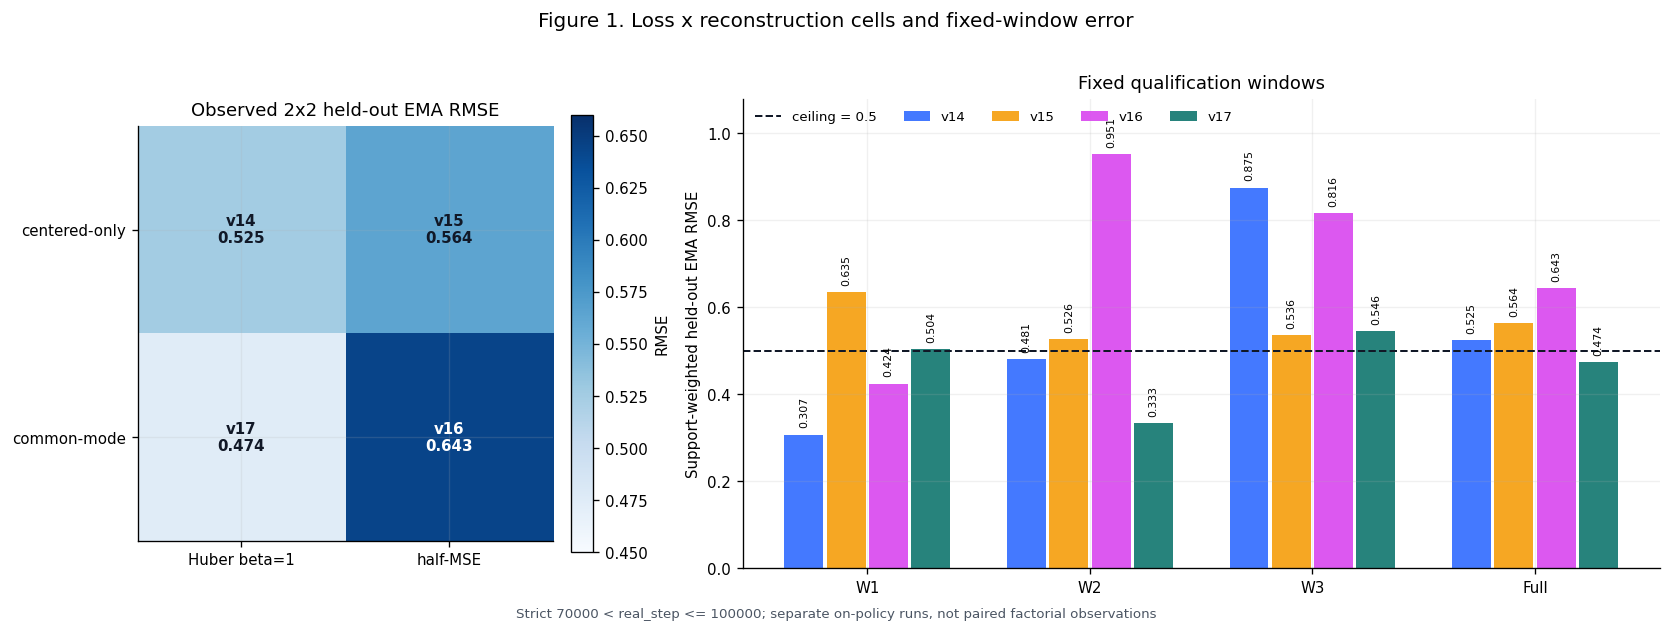

In [4]:
def summarize_calibration(version, frame, label, lower, upper):
    window = frame.loc[(frame.real_step > lower) & (frame.real_step <= upper)]
    support = int(require_counts(window[HOLDOUT_COUNT], HOLDOUT_COUNT).sum())
    ema_rmse = pooled_rmse(window, 'actor/voc_gate_holdout_td_rmse')
    ema_sse = support * ema_rmse**2
    threshold_sse = support * RMSE_CEILING**2
    return {
        'version': version, 'window': label, 'rows': len(window), 'support': support,
        'ema_bias': pooled_mean(window, 'actor/voc_gate_holdout_td_bias', HOLDOUT_COUNT),
        'ema_mae': pooled_mean(window, 'actor/voc_gate_holdout_td_mae', HOLDOUT_COUNT),
        'ema_rmse': ema_rmse, 'online_rmse': pooled_rmse(window, 'actor/voc_holdout_td_rmse'),
        'ema_sse': ema_sse, 'threshold_sse': threshold_sse, 'excess_sse': ema_sse - threshold_sse,
        'relative_sse_reduction_to_ceiling': max(0.0, (ema_sse - threshold_sse) / ema_sse),
    }

calibration_rows = []
for version, frame in canonical.items():
    calibration_rows.extend(summarize_calibration(version, frame, label, lower, upper) for label, lower, upper in WINDOWS)
    calibration_rows.append(summarize_calibration(version, frame, 'Full', LOWER_STEP, UPPER_STEP))
calibration = pd.DataFrame(calibration_rows)
expected_window_rmse = {
    ('v14', 'W1'): 0.3070468494240733, ('v14', 'W2'): 0.4805763254032396, ('v14', 'W3'): 0.8753410807478021, ('v14', 'Full'): 0.5247954789453232,
    ('v15', 'W1'): 0.6350000482991449, ('v15', 'W2'): 0.5262197892944133, ('v15', 'W3'): 0.5362964249791570, ('v15', 'Full'): 0.5637126651551874,
    ('v16', 'W1'): 0.42412219735332535, ('v16', 'W2'): 0.9513859413944138, ('v16', 'W3'): 0.8161048402729426, ('v16', 'Full'): 0.6433996228747740,
    ('v17', 'W1'): 0.5044903887648509, ('v17', 'W2'): 0.3328853383580048, ('v17', 'W3'): 0.5455878532763281, ('v17', 'Full'): 0.4739621233029751,
}
for row in calibration.itertuples(index=False):
    assert np.isclose(row.ema_rmse, expected_window_rmse[(row.version, row.window)], rtol=0.0, atol=1e-14)
full_sse = calibration.loc[calibration.window == 'Full'].reset_index(drop=True)
assert np.isclose(full_sse.set_index('version').loc['v16', 'ema_sse'], 3119.2117679806, rtol=0.0, atol=1e-10)
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(calibration)
    display(full_sse[['version', 'support', 'ema_rmse', 'ema_sse', 'threshold_sse', 'excess_sse', 'relative_sse_reduction_to_ceiling']])

order = ['W1', 'W2', 'W3', 'Full']
fig, axes = plt.subplots(1, 2, figsize=(14.0, 4.9), gridspec_kw={'width_ratios': [0.82, 1.65]})
matrix = np.array([[authoritative['v14']['heldout_ema_rmse'], authoritative['v15']['heldout_ema_rmse']], [authoritative['v17']['heldout_ema_rmse'], authoritative['v16']['heldout_ema_rmse']]])
matrix_versions = np.array([['v14', 'v15'], ['v17', 'v16']])
image = axes[0].imshow(matrix, cmap='Blues', vmin=0.45, vmax=0.66, aspect='equal')
axes[0].set_xticks([0, 1], ['Huber beta=1', 'half-MSE'])
axes[0].set_yticks([0, 1], ['centered-only', 'common-mode'])
axes[0].set_title('Observed 2x2 held-out EMA RMSE')
for row in range(2):
    for column in range(2):
        value, version = matrix[row, column], matrix_versions[row, column]
        axes[0].text(column, row, f'{version}\n{value:.3f}', ha='center', va='center', color='#111827' if value < 0.59 else 'white', fontweight='bold')
fig.colorbar(image, ax=axes[0], fraction=0.048, pad=0.04, label='RMSE')
x = np.arange(len(order), dtype=float)
width = 0.19
offsets = (np.arange(len(VERSIONS)) - (len(VERSIONS) - 1) / 2) * width
for offset, version in zip(offsets, VERSIONS):
    rows = calibration.loc[calibration.version == version].set_index('window').loc[order]
    bars = axes[1].bar(x + offset, rows.ema_rmse, width=width * 0.92, label=version, color=COLORS[version], alpha=0.9)
    for bar, value in zip(bars, rows.ema_rmse):
        axes[1].text(bar.get_x() + bar.get_width() / 2, value + 0.016, f'{value:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=90)
axes[1].axhline(RMSE_CEILING, color='#111827', linewidth=1.2, linestyle='--', label='ceiling = 0.5')
axes[1].set_xticks(x, order)
axes[1].set_ylim(0, 1.08)
axes[1].set_ylabel('Support-weighted held-out EMA RMSE')
axes[1].set_title('Fixed qualification windows')
axes[1].legend(ncol=5, frameon=False, loc='upper left', fontsize=8)
fig.suptitle('Figure 1. Loss x reconstruction cells and fixed-window error', fontsize=12, y=1.02)
fig.text(0.5, -0.01, 'Strict 70000 < real_step <= 100000; separate on-policy runs, not paired factorial observations', ha='center', color='#4B5563', fontsize=8)
fig.tight_layout()
plt.show()
rendered_figure_count += 1


### 3. Train/held-out moments and row-level bias/variance

The logged combined moments contain train plus holdout sufficient statistics; subtracting the held-out sums reconstructs train moments exactly. This is not a controlled generalization experiment because the gate changes the on-policy trajectory and the four runs have different supports.

For held-out EMA residuals, `MSE = within-row variance + between-row bias variance + pooled bias^2`. The decomposition is exact for the logged row aggregates. `Between-row` reflects changing row mean residuals; it is not between-seed/model variance.


,version,q_source,split,support,bias,mae,rmse
0,v14,EMA,train,54013,0.0001757239,0.2257031850,0.5865118456
1,v14,EMA,holdout,7703,-0.0173424071,0.2182068335,0.5247954789
2,v14,Online,train,54013,0.0004707586,0.2268510069,0.5867927997
3,v14,Online,holdout,7703,-0.0168082496,0.2190239446,0.5248123567
4,v15,EMA,train,57906,-0.0034510450,0.1969348060,0.4891362534
5,v15,EMA,holdout,8154,0.0058673889,0.2649639505,0.5637126652
6,v15,Online,train,57906,-0.0030080349,0.1991153192,0.4894692565
7,v15,Online,holdout,8154,0.0061157450,0.2675517220,0.5646944858
8,v16,EMA,train,52672,0.0168319447,0.2661945921,0.5999551131
9,v16,EMA,holdout,7535,0.0120960360,0.3013661225,0.6433996229


,version,ema_mse,pooled_bias,within_row_variance,between_row_bias_variance,pooled_bias_squared,within_share,between_share,bias_squared_share
0,v14,0.2754102947,-0.0173424071,0.1785494537,0.0965600819,0.0003007591,0.6483034844,0.3506044755,0.0010920401
1,v15,0.3177719689,0.0058673889,0.1892163488,0.1285211938,0.0000344263,0.5954469473,0.4044447163,0.0001083363
2,v16,0.4139630747,0.0120960360,0.2616547655,0.1521619951,0.0001463141,0.6320727174,0.3675738354,0.0003534472
3,v17,0.2246400943,0.0722080491,0.1484540013,0.0709720907,0.0052140024,0.6608526484,0.3159368807,0.0232104708


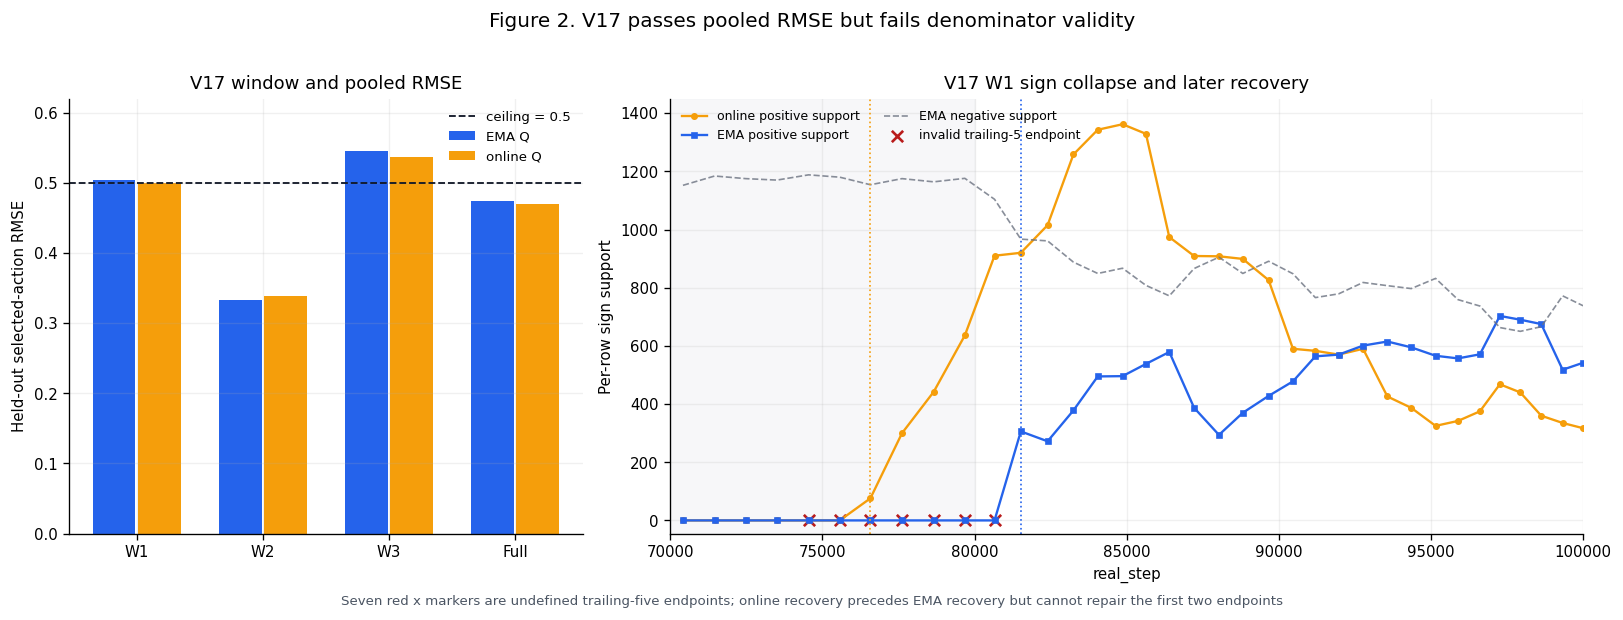

In [5]:
def reconstruct_split_moments(version, frame, source_label, prefix):
    train_n = require_counts(frame['actor/voc_continue_support'], 'train continue') + require_counts(frame['actor/voc_stop_support'], 'train stop')
    holdout_n = require_counts(frame[HOLDOUT_COUNT], HOLDOUT_COUNT)
    all_n = train_n + holdout_n
    all_bias = frame[f'{prefix}_td_bias'].to_numpy(dtype=np.float64)
    all_mae = frame[f'{prefix}_td_mae'].to_numpy(dtype=np.float64)
    all_rmse = frame[f'{prefix}_td_rmse'].to_numpy(dtype=np.float64)
    holdout_bias = frame[f'{prefix}_holdout_td_bias'].to_numpy(dtype=np.float64)
    holdout_mae = frame[f'{prefix}_holdout_td_mae'].to_numpy(dtype=np.float64)
    holdout_rmse = frame[f'{prefix}_holdout_td_rmse'].to_numpy(dtype=np.float64)
    train_sum = np.sum(all_n * all_bias - holdout_n * holdout_bias)
    train_abs = np.sum(all_n * all_mae - holdout_n * holdout_mae)
    train_sse = np.sum(all_n * np.square(all_rmse) - holdout_n * np.square(holdout_rmse))
    assert train_abs >= 0 and train_sse >= 0
    return [
        {'version': version, 'q_source': source_label, 'split': 'train', 'support': int(train_n.sum()), 'bias': train_sum / train_n.sum(), 'mae': train_abs / train_n.sum(), 'rmse': np.sqrt(train_sse / train_n.sum())},
        {'version': version, 'q_source': source_label, 'split': 'holdout', 'support': int(holdout_n.sum()), 'bias': np.dot(holdout_n, holdout_bias) / holdout_n.sum(), 'mae': np.dot(holdout_n, holdout_mae) / holdout_n.sum(), 'rmse': np.sqrt(np.dot(holdout_n, np.square(holdout_rmse)) / holdout_n.sum())},
    ]

split_rows = []
for version, frame in canonical.items():
    split_rows.extend(reconstruct_split_moments(version, frame, 'EMA', 'actor/voc_gate'))
    split_rows.extend(reconstruct_split_moments(version, frame, 'Online', 'actor/voc'))
split_moments = pd.DataFrame(split_rows)
expected_split_rmse = {
    ('v14', 'EMA', 'train'): 0.5865118456123475, ('v14', 'EMA', 'holdout'): 0.5247954789453232,
    ('v14', 'Online', 'train'): 0.5867927997052582, ('v14', 'Online', 'holdout'): 0.5248123566562356,
    ('v15', 'EMA', 'train'): 0.48913625344503686, ('v15', 'EMA', 'holdout'): 0.5637126651551874,
    ('v15', 'Online', 'train'): 0.48946925650925704, ('v15', 'Online', 'holdout'): 0.5646944857965209,
    ('v16', 'EMA', 'train'): 0.5999551130525911, ('v16', 'EMA', 'holdout'): 0.6433996228747740,
    ('v16', 'Online', 'train'): 0.5997760072212164, ('v16', 'Online', 'holdout'): 0.6432134673573406,
    ('v17', 'EMA', 'train'): 0.6696040559045617, ('v17', 'EMA', 'holdout'): 0.4739621233029751,
    ('v17', 'Online', 'train'): 0.6689091558309008, ('v17', 'Online', 'holdout'): 0.4695661556492494,
}
for row in split_moments.itertuples(index=False):
    assert np.isclose(row.rmse, expected_split_rmse[(row.version, row.q_source, row.split)], rtol=0.0, atol=1e-14), (row.version, row.q_source, row.split)

decomposition_rows = []
for version, frame in canonical.items():
    holdout_n = require_counts(frame[HOLDOUT_COUNT], HOLDOUT_COUNT).astype(np.float64)
    row_bias = frame['actor/voc_gate_holdout_td_bias'].to_numpy(dtype=np.float64)
    row_rmse = frame['actor/voc_gate_holdout_td_rmse'].to_numpy(dtype=np.float64)
    total_n = holdout_n.sum()
    pooled_bias = np.dot(holdout_n, row_bias) / total_n
    total_mse = np.dot(holdout_n, np.square(row_rmse)) / total_n
    within_row_variance = np.dot(holdout_n, np.square(row_rmse) - np.square(row_bias)) / total_n
    between_row_bias_variance = np.dot(holdout_n, np.square(row_bias - pooled_bias)) / total_n
    pooled_bias_squared = pooled_bias**2
    assert np.isclose(total_mse, within_row_variance + between_row_bias_variance + pooled_bias_squared, rtol=0.0, atol=1e-14)
    decomposition_rows.append({
        'version': version, 'ema_mse': total_mse, 'pooled_bias': pooled_bias,
        'within_row_variance': within_row_variance, 'between_row_bias_variance': between_row_bias_variance,
        'pooled_bias_squared': pooled_bias_squared, 'within_share': within_row_variance / total_mse,
        'between_share': between_row_bias_variance / total_mse, 'bias_squared_share': pooled_bias_squared / total_mse,
    })
error_structure = pd.DataFrame(decomposition_rows)
assert np.isclose(error_structure.set_index('version').loc['v16', 'ema_mse'], 0.4139630747154015, rtol=0.0, atol=1e-14)
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(split_moments)
    display(error_structure)

v17_windows = calibration.loc[calibration.version == 'v17'].set_index('window').loc[['W1', 'W2', 'W3', 'Full']]
v17_frame = canonical['v17']
online_positive = require_counts(v17_frame['actor/voc_acceptance_delta_q_positive_count'], 'v17 online positive')
ema_positive = require_counts(v17_frame[f'{GATE_PREFIX}_delta_q_positive_count'], 'v17 EMA positive')
online_negative = require_counts(v17_frame['actor/voc_acceptance_delta_q_negative_count'], 'v17 online negative')
ema_negative = require_counts(v17_frame[f'{GATE_PREFIX}_delta_q_negative_count'], 'v17 EMA negative')
online_canonical_reappearance = int(v17_frame.loc[online_positive > 0, 'real_step'].iloc[0])
ema_canonical_reappearance = int(v17_frame.loc[ema_positive > 0, 'real_step'].iloc[0])
assert online_canonical_reappearance == 76576 and ema_canonical_reappearance == 81520
v17_full_frame = frames['v17']
online_full_positive = require_counts(v17_full_frame['actor/voc_acceptance_delta_q_positive_count'], 'v17 full online positive')
ema_full_positive = require_counts(v17_full_frame[f'{GATE_PREFIX}_delta_q_positive_count'], 'v17 full EMA positive')
assert int(v17_full_frame.loc[v17_full_frame.real_step == 62128, 'actor/voc_acceptance_delta_q_positive_count'].iloc[0]) > 0
assert int(online_full_positive[(v17_full_frame.real_step >= 62992) & (v17_full_frame.real_step <= 75568)].sum()) == 0
assert int(v17_full_frame.loc[v17_full_frame.real_step == 76576, 'actor/voc_acceptance_delta_q_positive_count'].iloc[0]) > 0
assert int(v17_full_frame.loc[v17_full_frame.real_step == 69424, f'{GATE_PREFIX}_delta_q_positive_count'].iloc[0]) > 0
assert int(ema_full_positive[(v17_full_frame.real_step >= 70416) & (v17_full_frame.real_step <= 80656)].sum()) == 0
assert int(v17_full_frame.loc[v17_full_frame.real_step == 81520, f'{GATE_PREFIX}_delta_q_positive_count'].iloc[0]) > 0
assert (int(online_positive[v17_frame.real_step <= 80000].sum()), int(ema_positive[v17_frame.real_step <= 80000].sum())) == (1454, 0)
invalid_v17_steps = trailing_results['v17'].loc[trailing_results['v17'].positive_n == 0, 'real_step'].to_numpy(dtype=int)
fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.8), gridspec_kw={'width_ratios': [0.9, 1.6]})
x = np.arange(4)
axes[0].bar(x - 0.18, v17_windows.ema_rmse, width=0.34, color='#2563EB', label='EMA Q')
axes[0].bar(x + 0.18, v17_windows.online_rmse, width=0.34, color='#F59E0B', label='online Q')
axes[0].axhline(RMSE_CEILING, color='#111827', linestyle='--', linewidth=1.1, label='ceiling = 0.5')
axes[0].set_xticks(x, ['W1', 'W2', 'W3', 'Full'])
axes[0].set_ylim(0, 0.62)
axes[0].set_ylabel('Held-out selected-action RMSE')
axes[0].set_title('V17 window and pooled RMSE')
axes[0].legend(frameon=False, fontsize=8)
steps = v17_frame.real_step.to_numpy(dtype=int)
axes[1].plot(steps, online_positive, color='#F59E0B', marker='o', markersize=3.2, linewidth=1.4, label='online positive support')
axes[1].plot(steps, ema_positive, color='#2563EB', marker='s', markersize=3.0, linewidth=1.4, label='EMA positive support')
axes[1].plot(steps, ema_negative, color='#6B7280', linewidth=1.0, linestyle='--', alpha=0.8, label='EMA negative support')
axes[1].scatter(invalid_v17_steps, np.zeros_like(invalid_v17_steps), marker='x', s=46, color='#B91C1C', linewidth=1.6, label='invalid trailing-5 endpoint')
axes[1].axvspan(70000, 80000, color='#F3F4F6', alpha=0.65, zorder=-1)
axes[1].axvline(online_canonical_reappearance, color='#F59E0B', linestyle=':', linewidth=1.0)
axes[1].axvline(ema_canonical_reappearance, color='#2563EB', linestyle=':', linewidth=1.0)
axes[1].set_xlim(70000, 100000)
axes[1].set_ylim(-45, 1450)
axes[1].set_xlabel('real_step')
axes[1].set_ylabel('Per-row sign support')
axes[1].set_title('V17 W1 sign collapse and later recovery')
axes[1].legend(frameon=False, fontsize=7.5, ncol=2, loc='upper left')
fig.suptitle('Figure 2. V17 passes pooled RMSE but fails denominator validity', fontsize=12, y=1.02)
fig.text(0.5, -0.01, 'Seven red x markers are undefined trailing-five endpoints; online recovery precedes EMA recovery but cannot repair the first two endpoints', ha='center', color='#4B5563', fontsize=8)
fig.tight_layout()
plt.show()
rendered_figure_count += 1


### 4. Tail observability, composition, and update norms

`Top-k row SSE share` measures concentration across logged rows, not event-level residual quantiles. V14 and v17 log Huber beta=1 and permit the exact excess squared-error-energy identity against reconstructed half-MSE; v15/v16 log half-MSE directly. The tail-energy fraction is not a sample fraction, gradient fraction, or causal contribution.

Composition and cadence are reported rather than normalized away. V17 has 36 canonical rows versus 52–63 for v14–v16, median step gap 800, and W1 zero EMA-positive support. Update norms are logged raw VoC-Q total gradient norms, not parameter deltas. The unchanged nominal clip boundary is `0.5 * 201 * 16 = 1608`; there is no separate post-clip norm or clipping counter, so the notebook reports finite raw-norm boundary exceedances rather than inventing telemetry. Cross-version associations do not prove a mechanism.


,version,top_rows,sse,share_of_total_sse
0,v14,1,311.1193808693,0.1466516650
1,v14,5,1157.0343518924,0.5453887626
2,v14,10,1696.9867775455,0.7999049616
3,v15,1,342.7880044517,0.1322937490
4,v15,5,1287.2144514304,0.4967805855
5,v15,10,1798.0507853628,0.6939299982
6,v16,1,492.2218407676,0.1578032777
7,v16,5,1615.3239165497,0.5178628566
8,v16,10,2310.8044459714,0.7408296127
9,v17,1,309.8489329062,0.2399639336


,version,logged_loss_definition,logged_loss,reconstructed_train_half_mse,mse_minus_2huber,tail_energy_fraction
0,v14,Huber beta=1,0.1242177419,0.1721628949,0.0958903061,0.2784871448
1,v15,half-MSE,0.1197900774,0.1197900765,NaN,NaN
2,v16,half-MSE,0.1798656289,0.1798656294,NaN,NaN
3,v17,Huber beta=1,0.1706039929,0.2237197294,0.1062314729,0.2374208864


,version,train_continue,train_stop,train_stop_fraction,holdout_continue,holdout_stop,holdout_stop_fraction,accept_positive,accept_negative,accept_positive_fraction,W1_support_share,W2_support_share,W3_support_share,W3_accept_positive,W3_accept_negative
0,v14,28219,25794,0.4775517005,4016,3687,0.4786446839,32458,29257,0.5259337276,0.4734519019,0.3226015838,0.2039465143,1023,11408
1,v15,31359,26547,0.4584499016,4365,3789,0.4646799117,36718,29339,0.5558532782,0.3007113073,0.4303409370,0.2689477557,6916,10701
2,v16,26897,25775,0.4893491798,3858,3677,0.4879893829,30798,29408,0.5115437000,0.6132714001,0.1927007299,0.1940278699,1,11722
3,v17,13360,26758,0.6669824019,1926,3822,0.6649269311,12788,33077,0.2788182710,0.2541753653,0.3321155184,0.4137091162,8245,10632


,version,nominal_clip_boundary,all_csv_rows,all_csv_boundary_exceedances,canonical_rows,canonical_boundary_exceedances
0,v14,1608.0000000000,204,0,63,0
1,v15,1608.0000000000,149,1,58,0
2,v16,1608.0000000000,250,35,52,7
3,v17,1608.0000000000,143,14,36,5


,version,all_csv_rows,canonical_rows,median_real_step_gap,mean_real_step_gap,train_support,train_support_per_update
0,v14,204,63,480.0000000000,473.2903225806,54013,857.3492063492
1,v15,149,58,544.0000000000,520.7017543860,57906,998.3793103448
2,v16,250,52,496.0000000000,576.0000000000,52672,1012.9230769231
3,v17,143,36,800.0000000000,845.2571428571,40118,1114.3888888889


,version,window,updates,train_support,train_support_per_update,logged_q_loss,reconstructed_train_half_mse,q_raw_norm_mean,q_raw_norm_median,q_raw_norm_p95,q_raw_norm_max
0,v14,W1,32,26203,818.8437500000,0.0302336039,0.0320744263,43.7297306061,35.3293666840,90.1979179382,129.2094879150
1,v14,W2,19,16949,892.0526315789,0.0725517989,0.0957707799,106.7384317298,110.8502883911,209.8414901733,289.9289245605
2,v14,W3,12,10861,905.0833333333,0.4315883740,0.6293499035,391.3856321971,313.6181488037,864.6222351074,886.3068847656
3,v14,Full,63,54013,857.3492063492,0.1242177419,0.1721628949,128.9525264861,62.3866691589,443.1804840088,886.3068847656
4,v15,W1,19,17739,933.6315789474,0.1709406693,0.1709406684,218.9079712316,132.3802490234,753.0468688965,767.4251708984
5,v15,W2,26,24741,951.5769230769,0.1041303743,0.1041303740,185.8801991389,119.6521339417,483.4906158447,802.5406494141
6,v15,W3,13,15426,1186.6153846154,0.0860857059,0.0860857041,119.5373567434,138.9091644287,191.8820678711,220.8452606201
7,v15,Full,58,57906,998.3793103448,0.1197900774,0.1197900765,181.8296942875,131.7394409180,537.2278793335,802.5406494141
8,v16,W1,32,32171,1005.3437500000,0.0595933142,0.0595933128,523.1005339622,345.3625793457,1637.2273437500,1712.2170410156
9,v16,W2,10,10240,1024.0000000000,0.2386107571,0.2386107560,514.8573974609,419.7950134277,1048.7463592529,1339.7142333984


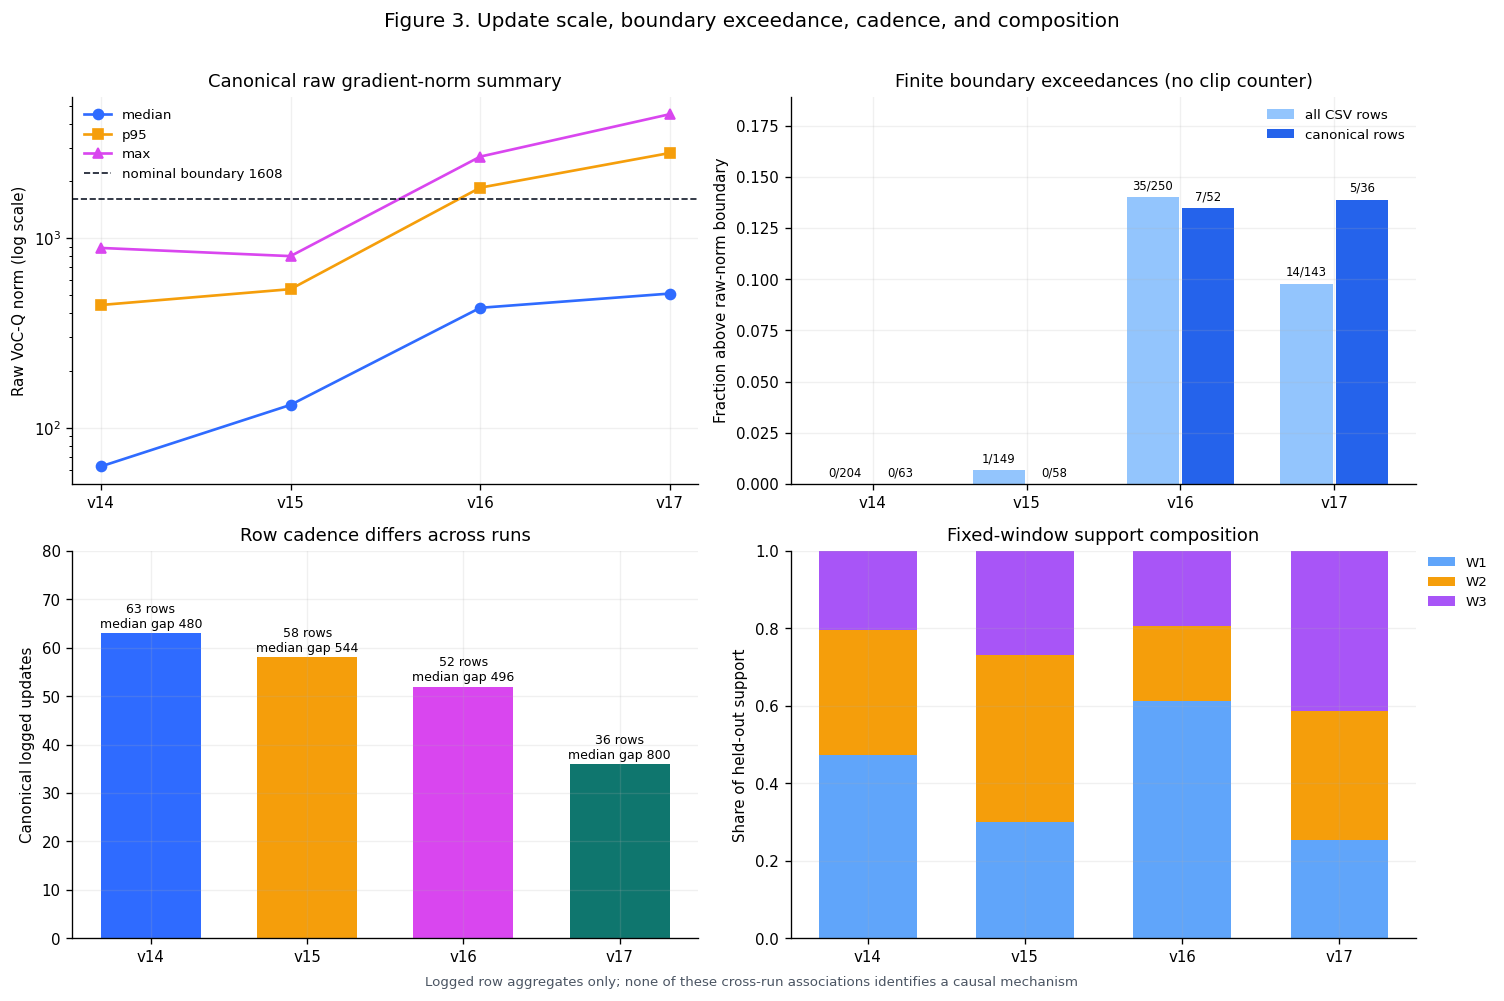

In [6]:
concentration_rows, tail_rows, composition_rows, regime_rows, clip_rows, cadence_rows = [], [], [], [], [], []
VOC_Q_CLIP_BOUNDARY = 0.5 * 201 * 16
assert VOC_Q_CLIP_BOUNDARY == 1608.0
for version, frame in canonical.items():
    full_frame = frames[version]
    clip_rows.append({
        'version': version, 'nominal_clip_boundary': VOC_Q_CLIP_BOUNDARY,
        'all_csv_rows': len(full_frame),
        'all_csv_boundary_exceedances': int((full_frame['actor/voc_total_norm'] > VOC_Q_CLIP_BOUNDARY).sum()),
        'canonical_rows': len(frame),
        'canonical_boundary_exceedances': int((frame['actor/voc_total_norm'] > VOC_Q_CLIP_BOUNDARY).sum()),
    })
    holdout_n = require_counts(frame[HOLDOUT_COUNT], HOLDOUT_COUNT).astype(np.float64)
    row_rmse = frame['actor/voc_gate_holdout_td_rmse'].to_numpy(dtype=np.float64)
    row_sse = pd.Series(holdout_n * np.square(row_rmse)).sort_values(ascending=False)
    for top_k in (1, 5, 10):
        concentration_rows.append({
            'version': version, 'top_rows': top_k, 'sse': float(row_sse.head(top_k).sum()),
            'share_of_total_sse': float(row_sse.head(top_k).sum() / row_sse.sum()),
        })
    train_n = require_counts(frame['actor/voc_continue_support'], 'train continue') + require_counts(frame['actor/voc_stop_support'], 'train stop')
    all_n = train_n + holdout_n.astype(np.int64)
    train_sse_rows = (
        all_n * np.square(frame['actor/voc_td_rmse'].to_numpy(dtype=np.float64))
        - holdout_n * np.square(frame['actor/voc_holdout_td_rmse'].to_numpy(dtype=np.float64))
    )
    train_half_mse = float(train_sse_rows.sum() / (2.0 * train_n.sum()))
    logged_loss = float(np.dot(train_n, frame['actor/voc_q_loss'].to_numpy(dtype=np.float64)) / train_n.sum())
    tail_rows.append({
        'version': version, 'logged_loss_definition': VERSIONS[version]['loss'],
        'logged_loss': logged_loss, 'reconstructed_train_half_mse': train_half_mse,
        'mse_minus_2huber': 2.0 * (train_half_mse - logged_loss) if version in ('v14', 'v17') else np.nan,
        'tail_energy_fraction': (train_half_mse - logged_loss) / train_half_mse if version in ('v14', 'v17') else np.nan,
    })
    train_continue = int(require_counts(frame['actor/voc_continue_support'], 'train continue').sum())
    train_stop = int(require_counts(frame['actor/voc_stop_support'], 'train stop').sum())
    holdout_continue = int(require_counts(frame['actor/voc_holdout_continue_support'], 'holdout continue').sum())
    holdout_stop = int(require_counts(frame['actor/voc_holdout_stop_support'], 'holdout stop').sum())
    accept_positive = int(require_counts(frame[f'{GATE_PREFIX}_delta_q_positive_count'], 'accept positive').sum())
    accept_negative = int(require_counts(frame[f'{GATE_PREFIX}_delta_q_negative_count'], 'accept negative').sum())
    composition = {
        'version': version, 'train_continue': train_continue, 'train_stop': train_stop,
        'train_stop_fraction': train_stop / (train_continue + train_stop),
        'holdout_continue': holdout_continue, 'holdout_stop': holdout_stop,
        'holdout_stop_fraction': holdout_stop / (holdout_continue + holdout_stop),
        'accept_positive': accept_positive, 'accept_negative': accept_negative,
        'accept_positive_fraction': accept_positive / (accept_positive + accept_negative),
    }
    for label, lower, upper in WINDOWS:
        window = frame.loc[(frame.real_step > lower) & (frame.real_step <= upper)]
        composition[f'{label}_support_share'] = require_counts(window[HOLDOUT_COUNT], HOLDOUT_COUNT).sum() / holdout_n.sum()
        if label == 'W3':
            composition['W3_accept_positive'] = int(require_counts(window[f'{GATE_PREFIX}_delta_q_positive_count'], 'W3 accept positive').sum())
            composition['W3_accept_negative'] = int(require_counts(window[f'{GATE_PREFIX}_delta_q_negative_count'], 'W3 accept negative').sum())
    composition_rows.append(composition)
    step_gaps = np.diff(frame.real_step.to_numpy(dtype=np.int64))
    cadence_rows.append({
        'version': version, 'all_csv_rows': len(full_frame), 'canonical_rows': len(frame),
        'median_real_step_gap': float(np.median(step_gaps)), 'mean_real_step_gap': float(np.mean(step_gaps)),
        'train_support': int(train_n.sum()), 'train_support_per_update': float(train_n.sum() / len(frame)),
    })
    work = frame.copy()
    work['train_count'] = train_n
    work['train_half_mse'] = train_sse_rows / (2.0 * train_n)
    assert (work['actor/voc_optimizer_stepped'] == 1).all()
    assert (work['actor/voc_gate_optimizer_stepped'] == 0).all()
    assert (work['actor/voc_gate_projection_post_error_norm'] == 0).all()
    assert (work['actor/voc_update_count'] == work['actor/voc_ema_gate_update_count']).all()
    assert (work['actor/voc_update_count'] == work['actor/voc_gate_update_count']).all()
    assert np.all(np.diff(work['actor/voc_update_count']) == 1)
    for label, lower, upper in (*WINDOWS, ('Full', LOWER_STEP, UPPER_STEP)):
        window = work.loc[(work.real_step > lower) & (work.real_step <= upper)]
        window_support = int(window.train_count.sum())
        updates = int(window['actor/voc_optimizer_stepped'].sum())
        regime_rows.append({
            'version': version, 'window': label, 'updates': updates, 'train_support': window_support,
            'train_support_per_update': window_support / updates,
            'logged_q_loss': float(np.dot(window.train_count, window['actor/voc_q_loss']) / window_support),
            'reconstructed_train_half_mse': float(np.dot(window.train_count, window.train_half_mse) / window_support),
            'q_raw_norm_mean': float(window['actor/voc_total_norm'].mean()),
            'q_raw_norm_median': float(window['actor/voc_total_norm'].median()),
            'q_raw_norm_p95': float(window['actor/voc_total_norm'].quantile(0.95)),
            'q_raw_norm_max': float(window['actor/voc_total_norm'].max()),
        })

concentration = pd.DataFrame(concentration_rows)
tail_observability = pd.DataFrame(tail_rows)
composition = pd.DataFrame(composition_rows)
regimes = pd.DataFrame(regime_rows)
clip_summary = pd.DataFrame(clip_rows)
cadence = pd.DataFrame(cadence_rows)
full_regimes = regimes.loc[regimes.window == 'Full'].reset_index(drop=True)
expected_top10 = {'v14': 0.7999049615724924, 'v15': 0.6939299981526046, 'v16': 0.7408296126900793, 'v17': 0.8373002087229751}
for version, expected in expected_top10.items():
    actual = concentration.query('version == @version and top_rows == 10').share_of_total_sse.iloc[0]
    assert np.isclose(actual, expected, rtol=0.0, atol=1e-14)
assert np.isclose(full_regimes.set_index('version').loc['v16', 'q_raw_norm_median'], 428.2610778808594, rtol=0.0, atol=1e-12)
assert np.isclose(full_regimes.set_index('version').loc['v16', 'q_raw_norm_p95'], 1842.8370300292963, rtol=0.0, atol=1e-10)
assert clip_summary.set_index('version')[['all_csv_boundary_exceedances', 'canonical_boundary_exceedances']].to_dict('index') == {
    'v14': {'all_csv_boundary_exceedances': 0, 'canonical_boundary_exceedances': 0},
    'v15': {'all_csv_boundary_exceedances': 1, 'canonical_boundary_exceedances': 0},
    'v16': {'all_csv_boundary_exceedances': 35, 'canonical_boundary_exceedances': 7},
    'v17': {'all_csv_boundary_exceedances': 14, 'canonical_boundary_exceedances': 5},
}
assert composition.set_index('version').loc['v16', ['W3_accept_positive', 'W3_accept_negative']].astype(int).tolist() == [1, 11722]
with pd.option_context('display.float_format', lambda value: f'{value:.10f}'):
    display(concentration)
    display(tail_observability)
    display(composition)
    display(clip_summary)
    display(cadence)
    display(regimes)

fig, axes = plt.subplots(2, 2, figsize=(12.6, 8.0))
x = np.arange(len(VERSIONS), dtype=float)
norm_table = full_regimes.set_index('version').loc[list(VERSIONS)]
for column, label, marker, color in [('q_raw_norm_median', 'median', 'o', '#2F6BFF'), ('q_raw_norm_p95', 'p95', 's', '#F59E0B'), ('q_raw_norm_max', 'max', '^', '#D946EF')]:
    axes[0, 0].plot(x, norm_table[column], marker=marker, linewidth=1.6, label=label, color=color)
axes[0, 0].axhline(VOC_Q_CLIP_BOUNDARY, color='#111827', linestyle='--', linewidth=1.0, label='nominal boundary 1608')
axes[0, 0].set_xticks(x, list(VERSIONS))
axes[0, 0].set_yscale('log')
axes[0, 0].set_ylabel('Raw VoC-Q norm (log scale)')
axes[0, 0].set_title('Canonical raw gradient-norm summary')
axes[0, 0].legend(frameon=False, fontsize=8)
clip_indexed = clip_summary.set_index('version').loc[list(VERSIONS)]
all_rate = clip_indexed.all_csv_boundary_exceedances / clip_indexed.all_csv_rows
canonical_rate = clip_indexed.canonical_boundary_exceedances / clip_indexed.canonical_rows
axes[0, 1].bar(x - 0.18, all_rate, width=0.34, color='#93C5FD', label='all CSV rows')
axes[0, 1].bar(x + 0.18, canonical_rate, width=0.34, color='#2563EB', label='canonical rows')
for xpos, row in zip(x, clip_indexed.itertuples()):
    axes[0, 1].text(xpos - 0.18, all_rate.loc[row.Index] + 0.004, f'{row.all_csv_boundary_exceedances}/{row.all_csv_rows}', ha='center', fontsize=7)
    axes[0, 1].text(xpos + 0.18, canonical_rate.loc[row.Index] + 0.004, f'{row.canonical_boundary_exceedances}/{row.canonical_rows}', ha='center', fontsize=7)
axes[0, 1].set_xticks(x, list(VERSIONS))
axes[0, 1].set_ylim(0, max(all_rate.max(), canonical_rate.max()) * 1.28 + 0.01)
axes[0, 1].set_ylabel('Fraction above raw-norm boundary')
axes[0, 1].set_title('Finite boundary exceedances (no clip counter)')
axes[0, 1].legend(frameon=False, fontsize=8)
cadence_indexed = cadence.set_index('version').loc[list(VERSIONS)]
bars = axes[1, 0].bar(x, cadence_indexed.canonical_rows, color=[COLORS[v] for v in VERSIONS], width=0.64)
for bar, rows, gap in zip(bars, cadence_indexed.canonical_rows, cadence_indexed.median_real_step_gap):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, rows + 1.2, f'{int(rows)} rows\nmedian gap {int(gap)}', ha='center', fontsize=7.5)
axes[1, 0].set_xticks(x, list(VERSIONS))
axes[1, 0].set_ylim(0, cadence_indexed.canonical_rows.max() * 1.27)
axes[1, 0].set_ylabel('Canonical logged updates')
axes[1, 0].set_title('Row cadence differs across runs')
bottom = np.zeros(len(VERSIONS))
for label, color in zip(('W1', 'W2', 'W3'), ('#60A5FA', '#F59E0B', '#A855F7')):
    values = composition.set_index('version').loc[list(VERSIONS), f'{label}_support_share'].to_numpy()
    axes[1, 1].bar(x, values, bottom=bottom, width=0.62, label=label, color=color)
    bottom += values
axes[1, 1].set_xticks(x, list(VERSIONS))
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_ylabel('Share of held-out support')
axes[1, 1].set_title('Fixed-window support composition')
axes[1, 1].legend(frameon=False, ncol=1, fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0)
fig.suptitle('Figure 3. Update scale, boundary exceedance, cadence, and composition', fontsize=12, y=1.01)
fig.text(0.5, -0.005, 'Logged row aggregates only; none of these cross-run associations identifies a causal mechanism', ha='center', color='#4B5563', fontsize=8)
fig.tight_layout()
plt.show()
rendered_figure_count += 1


In [7]:
# Reproduce the A/B frozen-checkpoint coordinate diagnostic without training or mutation.
import contextlib
import io
import math
import torch

COORDINATE_CHECKPOINTS = {
    'v16_step480': (VERSIONS['v16']['snapshot'] / 'runs' / VERSIONS['v16']['xpid'] / 'ckp_actor.tar_step_480', '3a9f8f9199726902bf789afe7910f61c89f437cb4099476bcb709ecf6a06873c'),
    'v16_terminal': (VERSIONS['v16']['snapshot'] / 'runs' / VERSIONS['v16']['xpid'] / 'ckp_actor.tar_step_100432', 'ed9500695a774022f4587acf872441a308405324049cfae4b15cdb8dc252bcef'),
    'v17_step480': (VERSIONS['v17']['snapshot'] / 'runs' / VERSIONS['v17']['xpid'] / 'ckp_actor.tar_step_480', 'd93d16150136f67e8a9d200aefb31b7c2ecbb8a58ed01af4e092c02ce4669b66'),
    'v17_terminal': (VERSIONS['v17']['snapshot'] / 'runs' / VERSIONS['v17']['xpid'] / 'ckp_actor.tar_step_100000', '7d7eadebd7b333181efda0f40be310d85a4286fce4376b43304873b15456269c'),
}
for path, expected_hash in COORDINATE_CHECKPOINTS.values():
    assert path.is_file() and sha256_file(path) == expected_hash

def load_frozen_checkpoint(path):
    # Trusted, hash-bound experiment artifacts; suppress an unrelated legacy-Gym import notice.
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        return torch.load(path, map_location='cpu', weights_only=False)

v16_initial = load_frozen_checkpoint(COORDINATE_CHECKPOINTS['v16_step480'][0])
v17_initial = load_frozen_checkpoint(COORDINATE_CHECKPOINTS['v17_step480'][0])
v17_terminal = load_frozen_checkpoint(COORDINATE_CHECKPOINTS['v17_terminal'][0])
for container, key in (
    ('actor_net_state_dict', 'voc_head.weight'), ('actor_net_state_dict', 'voc_head.bias'),
    ('voc_ema_gate_head_state_dict', 'weight'), ('voc_ema_gate_head_state_dict', 'bias'),
    ('actor_net_state_dict', 'voc_gate_head.weight'), ('actor_net_state_dict', 'voc_gate_head.bias'),
):
    assert torch.equal(v16_initial[container][key], v17_initial[container][key])
for parameter_id in (0, 1):
    for field in ('step', 'exp_avg', 'exp_avg_sq'):
        left = v16_initial['voc_optimizer_state_dict']['state'][parameter_id][field]
        right = v17_initial['voc_optimizer_state_dict']['state'][parameter_id][field]
        assert torch.equal(left, right) if torch.is_tensor(left) else left == right

SQRT2 = math.sqrt(2.0)
def orthonormal_norms(rows):
    rows = rows.detach().double()
    assert rows.ndim >= 1 and rows.shape[0] == 2
    common = (rows[0] + rows[1]) / SQRT2
    difference = (rows[0] - rows[1]) / SQRT2
    return float(torch.linalg.vector_norm(common)), float(torch.linalg.vector_norm(difference))

online_weight = v17_terminal['actor_net_state_dict']['voc_head.weight']
ema_weight = v17_terminal['voc_ema_gate_head_state_dict']['weight']
gate_weight = v17_terminal['actor_net_state_dict']['voc_gate_head.weight']
gate_bias = v17_terminal['actor_net_state_dict']['voc_gate_head.bias']
ema_bias = v17_terminal['voc_ema_gate_head_state_dict']['bias']
assert torch.equal(gate_weight, 20 * (ema_weight[0] - ema_weight[1]).reshape(1, -1))
assert torch.equal(gate_bias, 20 * (ema_bias[0] - ema_bias[1]).reshape(1))

optimizer = v17_terminal['voc_optimizer_state_dict']
group = optimizer['param_groups'][0]
assert group['params'] == [0, 1]
weight_state = optimizer['state'][0]
moment = weight_state['exp_avg'].double()
second_moment = weight_state['exp_avg_sq'].double()
step = float(weight_state['step'])
beta1, beta2 = map(float, group['betas'])
learning_rate, epsilon = float(group['lr']), float(group['eps'])
assert (step, beta1, beta2, epsilon) == (143.0, 0.9, 0.999, 1e-08)

# Apply the frozen row denominators to isolated common-only/difference-only first moments.
vhat = second_moment / (1.0 - beta2**step)
def frozen_rowwise_adam_map(assumed_moment):
    return -learning_rate * (assumed_moment / (1.0 - beta1**step)) / (torch.sqrt(vhat) + epsilon)

common_mean = (moment[0] + moment[1]) / 2.0
difference_mean = (moment[0] - moment[1]) / 2.0
common_only_update = frozen_rowwise_adam_map(torch.stack([common_mean, common_mean]))
difference_only_update = frozen_rowwise_adam_map(torch.stack([difference_mean, -difference_mean]))
common_intended, common_leak = orthonormal_norms(common_only_update)
difference_leak, difference_intended = orthonormal_norms(difference_only_update)
coordinate_diagnostic = {
    'step480_v16_v17_online_ema_gate_adam_bitwise_equal': True,
    'v17_terminal_online_weight_common_difference_norm': orthonormal_norms(online_weight),
    'v17_terminal_ema_weight_common_difference_norm': orthonormal_norms(ema_weight),
    'v17_terminal_online_minus_ema_common_difference_norm': orthonormal_norms(online_weight - ema_weight),
    'v17_terminal_adam_first_moment_common_difference_norm': orthonormal_norms(moment),
    'common_to_difference_frozen_denominator_leakage_ratio': common_leak / common_intended,
    'difference_to_common_frozen_denominator_leakage_ratio': difference_leak / difference_intended,
    'projection_matches_current_ema_raw_difference_bitwise': True,
}
assert np.allclose(coordinate_diagnostic['v17_terminal_adam_first_moment_common_difference_norm'], (118.41179575543109, 61.27793259647075), rtol=0.0, atol=1e-12)
assert np.isclose(coordinate_diagnostic['common_to_difference_frozen_denominator_leakage_ratio'], 0.312531749799473, rtol=0.0, atol=1e-12)
assert np.isclose(coordinate_diagnostic['difference_to_common_frozen_denominator_leakage_ratio'], 0.3289216882682968, rtol=0.0, atol=1e-12)
display(pd.DataFrame([coordinate_diagnostic]).T.rename(columns={0: 'value'}))


,value
step480_v16_v17_online_ema_gate_adam_bitwise_equal,True
v17_terminal_online_weight_common_difference_norm,"(0.09197670854694069, 0.04772993647417535)"
v17_terminal_ema_weight_common_difference_norm,"(0.08804985021047274, 0.04523736449366637)"
v17_terminal_online_minus_ema_common_difference_norm,"(0.016672458740732386, 0.005328437961923289)"
v17_terminal_adam_first_moment_common_difference_norm,"(118.41179575543109, 61.27793259647075)"
common_to_difference_frozen_denominator_leakage_ratio,0.312532
difference_to_common_frozen_denominator_leakage_ratio,0.328922
projection_matches_current_ema_raw_difference_bitwise,True


## Evidence, causal limits, and ranked next-experiment hypotheses

### Frozen evidence

1. **The hard-gate outcomes are arithmetically determined.** V14 and v15 fail only the held-out EMA RMSE ceiling. V16 fails that ceiling (`0.6433996229`) and trailing-five denominator validity at five endpoints. V17 clears pooled RMSE (`0.4739621233`, N=5,748) but fails denominator validity at exactly seven endpoints: 74544, 75568, 76576, 77616, 78656, 79680, and 80656. All defined V16/V17 trailing-five endpoints are nonnegative; undefined endpoints remain hard failures.
2. **V17 improves the held-out aggregate while moving other diagnostics adversely.** Relative to V16, V17 held-out EMA RMSE is 26.3347% lower, but train EMA RMSE rises from `0.5999551131` to `0.6696040559`. Huber discounts reconstructed half-MSE row means by 23.7421% in aggregate, yet finite raw norms still exceed the nominal 1,608 boundary on 14/143 all rows and 5/36 canonical rows; the canonical maximum is `4498.306`. A bounded per-example Huber slope does not bound the aggregate norm.
3. **The V17 failure is an early EMA-positive-support extinction followed by recovery.** W1 EMA sign support is 0 positive / 11,718 negative, whereas online support is 1,454 / 10,264. Across the full run, online positive support collapses at 62992, remains zero through 75568, and returns at 76576; EMA positive support collapses at 70416, remains zero through 80656, and returns at 81520. Thus the first canonical reappearances differ by 4,944 steps, but a no-lag target cannot repair the first two observed invalid endpoints (74544 and 75568) on the frozen trajectory. W2/W3 recover positive support; the failure is neither a permanently one-sided terminal state nor a negative-gap run.
4. **Window composition and cadence differ materially.** V17 contributes 36 canonical rows versus 52–63 for earlier runs, its median logged step gap is 800, and W3 carries 41.37% of held-out support. V16 is W1-heavy (61.33%) while its W2/W3 RMSE is `0.9514/0.8161`; V17 shifts support later while its W1/W3 RMSE is `0.5045/0.5456`. No post-hoc row, window, cadence, or support reweighting is permitted.
5. **The common/difference optimizer diagnostic is reproducible but not causal.** Hash-bound V16/V17 step-480 checkpoints are bitwise equal for online-Q, EMA-Q, projected-gate, and both Q-Adam states. At the V17 terminal checkpoint, the weight first-moment common/difference norms are `118.4118/61.2779`. Applying the frozen rowwise Adam denominators separately to common-only and difference-only first moments yields 31.2532% common→difference and 32.8922% difference→common update leakage. This is a frozen-state diagnostic—not an actual next step, counterfactual update, or treatment-effect estimate.
6. **The 2×2 remains descriptive.** V14/V15/V16/V17 respectively observe Huber+centered, half-MSE+centered, half-MSE+common, and Huber+common. Held-out EMA RMSE is `0.5248/0.5637/0.6434/0.4740`, but the runs are separate single-seed policy-coupled trajectories with different states, supports, cadence, composition, and optimizer histories.

### What is not identified

There is one seed and one separately generated on-policy run per version, no paired state sequence, no counterfactual action residuals, and no randomized factorial isolation. Checkpoint diagnostics observe frozen tensors and optimizer states; they do not identify how a changed optimizer would alter the closed-loop trajectory. Therefore this notebook does **not** estimate a treatment effect, identify a unique root cause, predict a future pass, or authorize implementation, retry, primary, or fixed evaluation.

### A/B-consensus ranked V18 candidates — hypotheses only

1. **Schema-11 orthonormal common/difference Adam coordinates.** This was already the prospectively ranked second mechanism in the frozen V17 preregistration, before V17's outcome. Keep raw-head parameters, storage, and forward outputs exactly in `[CONTINUE, STOP]` rows. Only the optimizer adapter changes: after existing raw-gradient clipping, form `g_m=(g_C+g_S)/sqrt(2)` and `g_d=(g_C-g_S)/sqrt(2)`, maintain Adam moment rows as `[common, difference]`, and inverse-map the resulting update deltas to the unchanged raw C/S parameters. EMA and exact projection remain raw-row operations. A future preregistration would have to freeze this as one parameter-free optimizer-coordinate semantic, with proposed derived-only identity `voc_q_optimizer_coordinates="orthonormal_common_difference_adam"`, while retaining beta-1 Huber, the schema-10 forward reconstruction, tensor shapes and persisted keys, and every population/acceptance rule. Motivation is the exact coordinate algebra plus the frozen leakage diagnostic; neither proves that optimizer-coordinate mixing caused the sign collapse. Falsifier: the unchanged hard gates still fail, regardless of cleaner coordinate separation.
2. **EMA tau=1 as a no-lag ablation.** Replacing the lagged EMA target with the online target directly tests whether the observed 4,944-step recovery delay matters. It ranks second because the frozen online series itself has zero positive support through 75568 and therefore cannot repair the first two invalid endpoints on the observed path; faster EMA also changes future closed-loop states, so no counterfactual pass follows from the overlay. Falsifier: denominator validity or other unchanged gates still fail even when target lag is removed.
3. **Deterministic Q-update cadence.** V17 logs only 143 Q updates (36 canonical rows) with median canonical step gap 800, versus V16's 250/52/496. A cadence-only successor could test whether update timing contributes to the collapse while holding objective, reconstruction, optimizer coordinates, EMA, and gates fixed. It ranks third because logged cadence is an outcome of a different trajectory and its causal direction is not identified.

### Acceptance and monitoring requirement — not a model candidate

**Do not relax signed-support accounting.** Any successor must retain the same positive/negative sufficient statistics, endpoint-validity rule, strict population, windows, and trailing-five gate. Zero positive or negative support stays undefined/invalid, never zero or nonnegative. Restored sign support would be an observed outcome under a candidate, not permission to remove endpoints, change windows, alter support, or relax thresholds.

### Open evidence need — not a model candidate

**Add event-level residual telemetry before selecting further tail controls.** V17's top 10 rows carry 83.73% of held-out EMA SSE, but row aggregates cannot reveal event-tail quantiles or connect individual residuals to raw-norm excursions. New telemetry would discriminate later hypotheses; it would not change acceptance or identify a cause by itself.

**Rejected as evidence-driven second levers:** threshold/window/support relaxation, post-hoc row removal, rescue seeds, simultaneous loss/reconstruction/tau/cadence changes, and sign-balanced objective changes aimed directly at the failed metric. The ranking organizes falsifiable questions; it is not a V18 preregistration or design authorization.


In [8]:
assert rendered_figure_count == 3
audit = {
    'production_python': {'version': platform.python_version(), 'executable': str(Path(sys.executable).resolve())},
    'protocol_population': '70000 < real_step <= 100000',
    'actor_csv_sha256': {version: spec['actor_sha256'] for version, spec in VERSIONS.items()},
    'model_csv_sha256': {version: spec['model_sha256'] for version, spec in VERSIONS.items()},
    'actor_checkpoint_sha256': {version: spec['actor_checkpoint_sha256'] for version, spec in VERSIONS.items()},
    'model_checkpoint_sha256': {version: spec['model_checkpoint_sha256'] for version, spec in VERSIONS.items()},
    'config_sha256': {version: spec['config_sha256'] for version, spec in VERSIONS.items()},
    'finish_sha256': {version: spec['finish_sha256'] for version, spec in VERSIONS.items()},
    'source_manifest_sha256': {version: spec['source_manifest_sha256'] for version, spec in VERSIONS.items()},
    'data_manifest_sha256': {version: spec['data_manifest_sha256'] for version, spec in VERSIONS.items()},
    'prereg_sha256': {version: spec['protocol_sha256'] for version, spec in VERSIONS.items()},
    'canonical_population': {version: spec['canonical'] for version, spec in VERSIONS.items()},
    'heldout_ema_rmse': {version: authoritative[version]['heldout_ema_rmse'] for version in VERSIONS},
    'csv_observable_hard_gate_failures': failure_sets,
    'v16_zero_positive_trailing_five_endpoints': trailing_results['v16'].loc[trailing_results['v16'].positive_n == 0, 'real_step'].astype(int).tolist(),
    'v16_W3_acceptance_sign_support': {'positive': int(composition.set_index('version').loc['v16', 'W3_accept_positive']), 'negative': int(composition.set_index('version').loc['v16', 'W3_accept_negative'])},
    'v16_raw_q_boundary_exceedances': {'boundary': VOC_Q_CLIP_BOUNDARY, 'all_csv': '35/250', 'canonical': '7/52'},
    'v17_zero_positive_trailing_five_endpoints': trailing_results['v17'].loc[trailing_results['v17'].positive_n == 0, 'real_step'].astype(int).tolist(),
    'v17_canonical_positive_reappearance': {'online': online_canonical_reappearance, 'ema': ema_canonical_reappearance},
    'v17_full_positive_extinction': {'online': {'zero_from': 62992, 'zero_through': 75568, 'returns': 76576}, 'ema': {'zero_from': 70416, 'zero_through': 80656, 'returns': 81520}},
    'v17_W1_positive_support': {'online': int(online_positive[v17_frame.real_step <= 80000].sum()), 'ema': int(ema_positive[v17_frame.real_step <= 80000].sum())},
    'v17_raw_q_boundary_exceedances': {'boundary': VOC_Q_CLIP_BOUNDARY, 'all_csv': '14/143', 'canonical': '5/36'},
    'coordinate_checkpoint_sha256': {label: expected_hash for label, (_, expected_hash) in COORDINATE_CHECKPOINTS.items()},
    'v17_coordinate_diagnostic': coordinate_diagnostic,
    'v18_ranked_hypotheses': ['orthonormal_common_difference_adam', 'ema_tau_1', 'deterministic_q_update_cadence'],
    'embedded_figures': rendered_figure_count,
    'causal_effect_estimated': False,
    'pass_prediction_made': False,
    'v18_implementation_performed': False,
}
assert audit['production_python']['version'] == '3.10.21'
assert audit['v16_zero_positive_trailing_five_endpoints'] == [95344, 96368, 97392, 98416, 99408]
assert audit['v16_W3_acceptance_sign_support'] == {'positive': 1, 'negative': 11722}
assert audit['v17_zero_positive_trailing_five_endpoints'] == [74544, 75568, 76576, 77616, 78656, 79680, 80656]
assert audit['v17_canonical_positive_reappearance'] == {'online': 76576, 'ema': 81520}
assert audit['v17_W1_positive_support'] == {'online': 1454, 'ema': 0}
assert audit['v17_coordinate_diagnostic']['step480_v16_v17_online_ema_gate_adam_bitwise_equal'] is True
assert audit['v17_coordinate_diagnostic']['projection_matches_current_ema_raw_difference_bitwise'] is True
print(json.dumps(audit, indent=2, sort_keys=True))


{
  "actor_checkpoint_sha256": {
    "v14": "a86094cc3131bbe55bd5ac5995203cf8f3830ab36fbaf60e630306b0fe1d107c",
    "v15": "ee41fa3f0916f5b726b6cd448e12989abbe01554a69c6f4eb5ab8ed434cd2c7c",
    "v16": "c05a2237b495ff36fe633446e8236a93d2e07da9038f01781ac3b5026e947b7d",
    "v17": "1054956ebbb8a1b75cb1d2eed54611c90d785c83ee3fc9a7d6d40e2c85430eb0"
  },
  "actor_csv_sha256": {
    "v14": "6d72052279a59983d102bed3db767b3792b115d221f155cdd10d4dc29bbe85a8",
    "v15": "359eb6540a6265a2a5b8e77fa8ac01420b5f0077a3b84d67800f0308f448e341",
    "v16": "45da4532357f5f150fad15c47bf1cdbb5ec52738ff3a68678afb5dca73ed20d5",
    "v17": "e50308619550a45e8bc722bd152722f96723f2b448885ae2e5ec65227f21d030"
  },
  "canonical_population": {
    "v14": {
      "first": 70032,
      "last": 99376,
      "overshoot": [
        100112
      ],
      "rows": 63,
      "support": 7703
    },
    "v15": {
      "first": 70240,
      "last": 99920,
      "overshoot": [
        100736
      ],
      "rows": 58,
      "s

## Takeaways

- Exact frozen bytes and the strict population reproduce V14/V15/V16/V17 held-out EMA RMSE at `0.5247954789/0.5637126652/0.6433996229/0.4739621233`. V17 alone clears RMSE, but its seven zero-positive trailing-five endpoints permanently fail qualification.
- V17's online recovery precedes EMA recovery by 4,944 steps, yet online remains zero-positive through 75568; tau=1 cannot repair the first two invalid endpoints on the observed trajectory.
- Huber+common improves held-out RMSE relative to V16 but worsens train RMSE and still has 5/36 canonical raw-norm boundary exceedances. Cadence, support composition, SSE concentration, and optimizer state all differ, so the 2×2 does not identify a causal mechanism.
- Independent A/B RCA ranks orthonormal common/difference Adam coordinates first, tau=1 second, and deterministic cadence third. The ranking is falsifiable experiment ordering only—not a pass prediction, preregistration, implementation, launch, evaluation, retry, rescue, or permission to change any acceptance gate.
